# 🧪 Lab — 2D Perception: Detection · Segmentation · Keypoints
**AICB · Computer Vision · Track 4 · Ngày 18** — 120 phút — Google Colab (GPU T4)

> 🏭 **Bài toán xuyên suốt.** Camera ở cổng nhà máy cần biết: **có bao nhiêu người**, **ai không đội mũ bảo hộ**, và **có ai vừa ngã**.
> Trong 120 phút bạn tự tay dựng từng mảnh của câu trả lời đó.

| Phần | Bạn làm gì | Mảnh ghép cho camera cổng | ⏱ |
|---|---|---|---|
| 0 | Setup, tải sẵn model và dữ liệu | — | 10' |
| 1 · Detection | Tự viết IoU + NMS, so sánh YOLO26 có NMS và NMS-free | Đếm người | 35' |
| 2 · Segmentation | Tự viết mask IoU, polygon ↔ mask, auto-label bằng SAM 2.1 | Tạo nhãn nhanh cho class mới (mũ bảo hộ) | 30' |
| 3 · Keypoints | Tự viết OKS và góc khớp, dựng luật "ngã" | Phát hiện người ngã | 25' |
| 4 · Fine-tune | Sửa `flip_idx`, train YOLO26n-pose trên tiger-pose, phân tích lỗi | Dạy model một đối tượng mới | 20' |

### Cách làm việc với notebook này
| Ký hiệu | Ý nghĩa |
|---|---|
| 🔮 **Dự đoán** | Tự nhẩm kết quả *trước khi* chạy ô. Không chấm điểm, nhưng đây là lúc bạn học được nhiều nhất. |
| 🧩 **TODO** | Điền code vào chỗ có `...`. Mỗi chỗ chỉ 1 dòng. Chạy ô là có phản hồi ✅ / ❌ ngay bên dưới. |
| 💡 **Gợi ý** | Bấm để mở. Kẹt quá 3 phút thì mở, đừng ngại. |
| 🚦 **Chốt** | Ô `gate(...)` cuối mỗi mục TODO. Chưa xong thì notebook dừng ở đó. |
| 🛟 **Phao** | Hết giờ của mục mà chưa xong: sửa thành `gate("...", lifeline=True)` để mượn bản thư viện và đi tiếp. Hàm mượn phao không được tính điểm. |
| ❓ **Câu hỏi** | Trả lời 2–4 câu vào chuỗi `Q1 = """ ... """` ngay bên dưới (12 câu cả bài). |
| ⭐ | Nâng cao, làm nếu còn thời gian hoặc về nhà. |

### Nộp gì?
Notebook đã **Restart & Run All** không lỗi + thư mục `submission/` do ô cuối cùng tạo ra (gồm `ket_qua.json` và `autolabel/bus.txt`). Chi tiết ở cuối notebook và trong `README.md`.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VinUni-AI20k/Track04-Day18-2D-perception-detection-segmentation-keypoints/blob/main/lab_2d_perception_student.ipynb)

---
## Phần 0 — Setup (10')
1. `Runtime → Change runtime type → T4 GPU`.
2. Chạy lần lượt 5 ô dưới đây. Ô thứ tư tải khoảng 0,8 GB weights và dữ liệu; trong lúc chờ hãy đọc trước mục 1A.

In [1]:
%pip install -q "ultralytics==8.4.171"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc, json, math, random, shutil, time, warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import ultralytics
import yaml
from scipy.optimize import linear_sum_assignment
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_keypoints, draw_segmentation_masks
from ultralytics import SAM, YOLO

warnings.filterwarnings("ignore")
torch.manual_seed(0); np.random.seed(0); random.seed(0)

GPU = torch.cuda.is_available()
DEVICE = "cuda" if GPU else "cpu"
ASSETS = Path(ultralytics.__file__).parent / "assets"          # 2 ảnh mẫu đi kèm package, không cần tải
IMG_BUS, IMG_ZIDANE = str(ASSETS / "bus.jpg"), str(ASSETS / "zidane.jpg")

print(f"torch {torch.__version__} | torchvision {torchvision.__version__} | ultralytics {ultralytics.__version__} | device = {DEVICE}")
if not GPU:
    print("⚠️  Không thấy GPU. Notebook vẫn chạy được, nhưng Phần 4 sẽ tự giảm epochs/imgsz và kết quả sẽ kém. Hãy bật T4.")

torch 2.11.0+cu126 | torchvision 0.26.0+cu126 | ultralytics 8.4.171 | device = cuda


In [3]:
# @title 🔧 Hàm tiện ích + bộ kiểm tra — chỉ cần chạy, không cần đọc
import inspect, re
from IPython.display import Markdown, display

G = globals()
PROGRESS = {}                                   # tên deliverable → "ok" | "lifeline"
PLACEHOLDER = "(viết câu trả lời của bạn ở đây)"
SECTIONS = {"1B": ["box_iou", "nms", "batched_nms"], "2B": ["mask_iou", "polygon_to_mask", "mask_to_yolo_seg"],
            "3B": ["oks"], "3C": ["joint_angle"], "4A": ["FLIP_IDX"]}
SIDE_COLORS = {"right": "#d62728", "left": "#1f77b4", "mid": "#ff7f0e"}


# ───────────────────────── hiển thị ─────────────────────────
def show(*images, titles=None, ncols=None, size=5.0):
    """Hiển thị nhiều ảnh cạnh nhau. Nhận torch uint8 (C,H,W) hoặc numpy (H,W,C) RGB."""
    n = len(images); ncols = ncols or n; nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for i, img in enumerate(images):
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu()
            img = img.permute(1, 2, 0).numpy() if img.ndim == 3 else img.numpy()
        axes.flat[i].imshow(img)
        if titles:
            axes.flat[i].set_title(titles[i], fontsize=11)
    plt.tight_layout(); plt.show()


def bgr_to_u8(img_bgr):
    """numpy BGR (cv2, Results.plot()) → torch uint8 RGB (3,H,W)."""
    return torch.from_numpy(np.ascontiguousarray(img_bgr[..., ::-1])).permute(2, 0, 1)


def show_table(rows, title=None):
    """In list[dict] thành bảng Markdown."""
    if not rows:
        return
    cols = list(rows[0].keys())
    fmt = lambda v: f"{v:.3f}" if isinstance(v, float) else str(v)
    md = (f"**{title}**\n\n" if title else "") + "| " + " | ".join(cols) + " |\n|" + "---|" * len(cols) + "\n"
    md += "\n".join("| " + " | ".join(fmt(r[c]) for c in cols) + " |" for r in rows)
    display(Markdown(md))


def draw_det(img, boxes, cls, conf, color, names):
    labels = [f"{names[int(k)]} {p:.2f}" for k, p in zip(cls, conf)]
    return draw_bounding_boxes(img, boxes, labels, width=3, colors=color, font_size=22)


def side_of(name):
    return "right" if name.startswith("right_") else "left" if name.startswith("left_") else "mid"


def plot_kpts(ax, img_rgb, kpts, names, title="", marker="o", size=70):
    """Vẽ keypoint lên ảnh: đỏ = right_*, xanh = left_*, cam = trục giữa."""
    ax.imshow(img_rgb); ax.axis("off"); ax.set_title(title, fontsize=10)
    ax.scatter(kpts[:, 0], kpts[:, 1], s=size, c=[SIDE_COLORS[side_of(n)] for n in names],
               edgecolors="white", linewidths=1.5, marker=marker)


# ───────────────────────── khung kiểm tra ─────────────────────────
class LabStop(AssertionError):
    """Dừng 'Run all' bằng một thông báo gọn, không in traceback."""

    def _render_traceback_(self):
        return [str(self)]


def _todo_left(fn):
    """Đếm số chỗ `...` còn lại trong mã nguồn của một hàm."""
    try:
        src = inspect.getsource(fn)
    except Exception:
        return 0
    return sum(bool(re.search(r"(^|=|return)\s*\.\.\.\s*(#.*)?$", ln.strip())) for ln in src.splitlines())


def _run(name, steps, quiet=False):
    """steps: list[(mô tả, hàm thử)] — hàm thử trả về None nếu đạt, hoặc một chuỗi gợi ý nếu sai."""
    if getattr(G.get(name), "_lifeline", False):
        PROGRESS[name] = "lifeline"
        if not quiet:
            print(f"🛟 {name}: đang dùng bản thư viện (phao). Muốn được tính điểm, hãy hoàn thành rồi chạy lại ô TODO.")
        return
    left = _todo_left(G.get(name)) if callable(G.get(name)) else 0
    if left:
        PROGRESS.pop(name, None)
        if not quiet:
            print(f"❌ {name} — còn {left} chỗ `...` chưa điền. Điền hết rồi chạy lại ô này.")
        return
    for desc, test in steps:
        try:
            hint = test()
        except Exception as e:
            txt = f"{type(e).__name__}: {e}"
            hint = "vẫn còn chỗ `...` chưa điền." if "ellipsis" in txt.lower() else f"code báo lỗi → {txt}"
        if hint:
            PROGRESS.pop(name, None)
            if not quiet:
                print(f"❌ {name} — {desc}\n   ↳ {hint}")
            return
    PROGRESS[name] = "ok"
    if not quiet:
        print(f"✅ {name} đạt ({len(steps)} phép thử)")


def _not_tensor(out, what="hàm"):
    if out is Ellipsis or out is None:
        return f"{what} đang trả về `{out}` — còn chỗ chưa điền."
    if not isinstance(out, torch.Tensor):
        return f"{what} phải trả về torch.Tensor, đang trả về {type(out).__name__}."


def _toy_boxes():
    return torch.tensor([[0., 0., 10., 10.], [5., 0., 15., 10.], [20., 20., 30., 30.]])   # A, B, C


def _rand_boxes(n, seed, size=640):
    g = torch.Generator().manual_seed(seed)
    xy = torch.rand(n, 2, generator=g) * size
    wh = torch.rand(n, 2, generator=g) * size / 4 + 4
    return torch.cat([xy, xy + wh], 1)


# ───────────────────────── 1B ─────────────────────────
def check_box_iou(quiet=False):
    from torchvision.ops import box_iou as ref
    t = _toy_boxes()
    f = lambda *a: G["box_iou"](*a)

    def shape():
        out = f(t, t[:2])
        if _not_tensor(out):
            return _not_tensor(out)
        if tuple(out.shape) != (3, 2):
            return f"IoU của 3 box × 2 box phải có shape (3, 2), bạn ra {tuple(out.shape)}. Xem lại broadcast: area_a[:, None] + area_b[None, :]."

    def same():
        d = f(t, t).diagonal()
        if not torch.allclose(d, torch.ones(3), atol=1e-5):
            return f"IoU của một box với chính nó phải = 1, bạn ra {[round(v, 3) for v in d.tolist()]}. Kiểm tra Bước 1 (diện tích) và Bước 4 (hợp = |A| + |B| − giao)."

    def disjoint():
        v = float(f(t[:1], t[2:])[0, 0])
        if abs(v) > 1e-6:
            return f"A và C không chạm nhau nên IoU phải = 0, bạn ra {v:.4f}. Ở Bước 3, (rb − lt) âm theo cả hai chiều thì tích lại dương → thêm .clamp(min=0)."

    def toy():
        v = float(f(t[:1], t[1:2])[0, 0])
        if abs(v - 1 / 3) > 1e-4:
            return f"IoU(A, B) phải = 50/150 = 0.3333, bạn ra {v:.4f}. Bước 2: góc trên-trái lấy max, góc dưới-phải lấy min."

    def rand():
        a, b = _rand_boxes(50, 1), _rand_boxes(70, 2)
        if not torch.allclose(f(a, b), ref(a, b), atol=1e-5):
            return "chưa khớp torchvision trên 50 × 70 box ngẫu nhiên — xem lại cả 4 bước."

    _run("box_iou", [("shape (N, M)", shape), ("box với chính nó", same), ("ví dụ A–B tính tay", toy),
                     ("hai box rời nhau", disjoint), ("so với torchvision", rand)], quiet)


def check_nms(quiet=False):
    from torchvision.ops import nms as ref
    t = _toy_boxes()
    f = lambda *a: G["nms"](*a)

    def needs():
        if PROGRESS.get("box_iou") is None:
            return "nms dùng box_iou — hãy làm cho box_iou đạt ✅ trước."

    def toy_strict():
        out = f(t, torch.tensor([0.9, 0.8, 0.7]), 0.3)
        if _not_tensor(out):
            return _not_tensor(out)
        got = out.tolist()
        if got == [0, 1, 2]:
            return "ngưỡng 0.3: B (IoU 0.333 với A) phải bị loại, nhưng bạn giữ cả 3. Bước 2 chưa lọc: order = rest[ious <= iou_thr]."
        if got in ([0], [0, 1]):
            return f"ngưỡng 0.3: phải giữ A và C, loại B; bạn ra {got}. Kiểm tra chiều so sánh ở Bước 2: giữ box có IoU <= ngưỡng, loại box có IoU > ngưỡng."
        if got != [0, 2]:
            return f"ngưỡng 0.3: kỳ vọng giữ [0, 2] (A và C), bạn ra {got}."

    def toy_loose():
        got = f(t, torch.tensor([0.9, 0.8, 0.7]), 0.5).tolist()
        if got != [0, 1, 2]:
            return f"ngưỡng 0.5: IoU(A, B) = 0.333 không vượt ngưỡng nên giữ cả 3, bạn ra {got}."

    def boundary():
        got = f(torch.tensor([[0., 0, 10, 10], [0, 0, 10, 5]]), torch.tensor([0.9, 0.8]), 0.5).tolist()
        if got != [0, 1]:
            return f"hai box có IoU đúng bằng 0.5, ngưỡng 0.5: chỉ loại khi IoU > ngưỡng nên phải giữ cả hai; bạn ra {got}. Bước 2 dùng <=, không phải <."

    def order():
        out = f(torch.tensor([[0., 0, 5, 5], [10, 10, 15, 15], [20, 20, 25, 25]]), torch.tensor([0.1, 0.9, 0.5]), 0.5)
        if out.dtype != torch.long or out.tolist() != [1, 2, 0]:
            return f"kết quả phải là LongTensor chỉ số, xếp theo score giảm dần: [1, 2, 0]; bạn ra {out.tolist()} ({out.dtype})."

    def rand():
        b = _rand_boxes(300, 3); s = torch.rand(300, generator=torch.Generator().manual_seed(4))
        for thr in (0.3, 0.5, 0.7):
            if not torch.equal(f(b, s, thr), ref(b, s, thr)):
                return f"chưa khớp torchvision trên 300 box ngẫu nhiên ở ngưỡng {thr}."

    _run("nms", [("cần box_iou", needs), ("ví dụ A, B, C — ngưỡng 0.3", toy_strict), ("ví dụ A, B, C — ngưỡng 0.5", toy_loose),
                 ("IoU đúng bằng ngưỡng", boundary), ("thứ tự + kiểu dữ liệu", order), ("so với torchvision", rand)], quiet)


def check_batched_nms(quiet=False):
    from torchvision.ops import batched_nms as ref
    t = _toy_boxes()
    f = lambda *a: G["batched_nms"](*a)

    def needs():
        if PROGRESS.get("nms") is None:
            return "batched_nms dùng nms — hãy làm cho nms đạt ✅ trước."

    def diff_class():
        out = f(t[:2], torch.tensor([0.9, 0.8]), torch.tensor([0, 1]), 0.3)
        if _not_tensor(out):
            return _not_tensor(out)
        if out.tolist() != [0, 1]:
            return f"A và B khác class nên phải giữ cả hai dù IoU = 0.333 > 0.3; bạn ra {out.tolist()}. Offset đã cộng vào toạ độ chưa?"

    def same_class():
        got = f(t[:2], torch.tensor([0.9, 0.8]), torch.tensor([1, 1]), 0.3).tolist()
        if got != [0]:
            return f"A và B cùng class thì B phải bị loại; bạn ra {got}. Offset phải bằng nhau cho các box cùng class."

    def rand():
        b = _rand_boxes(300, 3); s = torch.rand(300, generator=torch.Generator().manual_seed(4))
        c = torch.randint(0, 3, (300,), generator=torch.Generator().manual_seed(5))
        for thr in (0.3, 0.5, 0.7):
            if not torch.equal(f(b, s, c, thr), ref(b, s, c, thr)):
                return f"chưa khớp torchvision trên 300 box, 3 class ở ngưỡng {thr}."

    _run("batched_nms", [("cần nms", needs), ("hai box khác class", diff_class), ("hai box cùng class", same_class),
                         ("so với torchvision", rand)], quiet)


def check_average_precision(quiet=False):
    f = lambda *a: G["average_precision"](*a)
    tp = np.array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0]); conf = np.linspace(0.95, 0.25, 15)

    def perfect():
        v = f(np.array([1, 1]), np.array([0.9, 0.8]), 2)
        if v is Ellipsis or v is None:
            return "hàm đang trả về `...`."
        if abs(v - 1.0) > 1e-6:
            return f"2 dự đoán đều TP, 2 GT → AP phải = 1.0; bạn ra {v:.4f}."

    def nothing():
        v = f(np.array([0, 0, 0]), np.array([0.9, 0.8, 0.7]), 5)
        if abs(v) > 1e-6:
            return f"không có TP nào → AP phải = 0; bạn ra {v:.4f}."

    def shuffled():
        p = np.random.default_rng(0).permutation(15)
        if abs(f(tp[p], conf[p], 10) - f(tp, conf, 10)) > 1e-9:
            return "AP đổi khi xáo thứ tự đầu vào — tp phải được sắp theo conf giảm dần trước khi cộng dồn."

    def slide():
        v = f(tp, conf, 10)
        if abs(v - 0.535) > 0.01:
            wrong = float(np.mean(np.cumsum(tp) / np.arange(1, 16)))
            extra = " Có vẻ bạn chưa dùng envelope (Bước 2)." if abs(v - wrong) < 0.05 else ""
            return f"ví dụ trên slide (10 GT, 15 dự đoán) phải ra AP ≈ 0.535; bạn ra {v:.4f}.{extra}"

    _run("average_precision", [("mọi dự đoán đều đúng", perfect), ("không có TP", nothing),
                               ("không phụ thuộc thứ tự đầu vào", shuffled), ("ví dụ trên slide", slide)], quiet)


# ───────────────────────── 2B ─────────────────────────
def _fill(poly, h, w):
    m = np.zeros((h, w), np.uint8)
    cv2.fillPoly(m, [np.round(poly).astype(np.int32)], 1)
    return m.astype(bool)


def _np_iou(a, b):
    return float((a & b).sum() / max((a | b).sum(), 1))


def _parse_seg_line(line, h, w):
    parts = line.split()
    return int(parts[0]), np.array(parts[1:], dtype=float).reshape(-1, 2) * [w, h]


def check_mask_iou(quiet=False):
    f = lambda *a: G["mask_iou"](*a)
    A = torch.zeros(1, 100, 100, dtype=torch.bool); A[0, :50, :50] = True
    B = torch.zeros(1, 100, 100, dtype=torch.bool); B[0, 25:75, 25:75] = True

    def shape():
        out = f(torch.cat([A, B, A]), torch.cat([A, B]))
        if _not_tensor(out):
            return _not_tensor(out)
        if tuple(out.shape) != (3, 2):
            return f"3 mask × 2 mask phải ra ma trận (3, 2), bạn ra {tuple(out.shape)}. inter = a @ b.T; union = area_a[:, None] + area_b[None, :] − inter."

    def toy():
        v = float(f(A, B)[0, 0])
        if abs(v - 625 / 4375) > 1e-5:
            return f"hai hình vuông 50×50 lệch nhau 25 px: giao 625, hợp 4375 → IoU = 0.1429; bạn ra {v:.4f}."

    def same():
        d = f(torch.cat([A, B]), torch.cat([A, B])).diagonal()
        if not torch.allclose(d.float(), torch.ones(2), atol=1e-5):
            return f"IoU của mask với chính nó phải = 1, bạn ra {[round(v, 3) for v in d.tolist()]}."

    def rand():
        g = torch.Generator().manual_seed(0)
        m1 = torch.rand(4, 32, 40, generator=g) > 0.6; m2 = torch.rand(6, 32, 40, generator=g) > 0.4
        ref = torch.stack([torch.stack([(a & b).sum() / (a | b).sum() for b in m2]) for a in m1])
        if not torch.allclose(f(m1, m2).float(), ref.float(), atol=1e-5):
            return "chưa khớp cách tính bằng vòng lặp trên mask ngẫu nhiên."

    _run("mask_iou", [("shape (N, M)", shape), ("ví dụ hai hình vuông", toy), ("mask với chính nó", same), ("so với vòng lặp", rand)], quiet)


def check_polygon_to_mask(quiet=False):
    f = lambda *a: G["polygon_to_mask"](*a)

    def square():
        m = f(np.array([[10, 10], [60, 10], [60, 60], [10, 60]]), 100, 100)
        if not isinstance(m, np.ndarray) or m.dtype != bool or m.shape != (100, 100):
            return f"phải trả về numpy bool (100, 100); bạn ra {type(m).__name__} {getattr(m, 'dtype', '')} {getattr(m, 'shape', '')}."
        if m.sum() == 0:
            return "mask rỗng — bạn đã gọi cv2.fillPoly(mask, [pts], 1) chưa?"
        if abs(int(m.sum()) - 51 * 51) > 110:
            return f"hình vuông cạnh 50 phải tô khoảng 2601 pixel, bạn tô {int(m.sum())}."

    def wide():
        m = f(np.array([[10, 10], [90, 10], [10, 40]]), 50, 100)
        if m.shape != (50, 100) or not m[15, 30] or m[45, 90]:
            return "tam giác trên ảnh H=50, W=100 bị sai vị trí — toạ độ polygon là (x, y), mask là [y, x]."

    _run("polygon_to_mask", [("hình vuông", square), ("ảnh không vuông", wide)], quiet)


def check_mask_to_yolo_seg(quiet=False):
    f = lambda *a, **k: G["mask_to_yolo_seg"](*a, **k)
    H, W = 200, 300
    circle = np.zeros((H, W), np.uint8); cv2.circle(circle, (150, 100), 60, 1, -1); circle = circle.astype(bool)

    def fmt():
        line = f(circle, 3)
        if not isinstance(line, str) or not line.strip():
            return "phải trả về một chuỗi 'class x1 y1 x2 y2 ...' (đang rỗng hoặc sai kiểu)."
        parts = line.split()
        if parts[0] != "3":
            return f"token đầu phải là class id '3', bạn ra '{parts[0]}'."
        if (len(parts) - 1) % 2 or len(parts) < 7:
            return f"sau class id phải là các cặp (x, y), ít nhất 3 đỉnh; bạn có {len(parts) - 1} số."

    def normalized():
        vals = np.array(f(circle, 3).split()[1:], dtype=float)
        if vals.max() > 1.0 + 1e-6 or vals.min() < 0:
            return f"toạ độ phải nằm trong [0, 1], bạn có giá trị tới {vals.max():.2f}. Bước 3: x chia cho W, y chia cho H."

    def roundtrip():
        _, poly = _parse_seg_line(f(circle, 3), H, W)
        v = _np_iou(circle, _fill(poly, H, W))
        if v < 0.95:
            return f"vẽ lại polygon thì chỉ trùng {v:.2f} với mask gốc (cần > 0.95). Hay gặp: chia x cho H và y cho W (ngược)."

    def largest():
        for corner in ((5, 5), (190, 290)):
            m = circle.copy(); m[corner[0]:corner[0] + 5, corner[1]:corner[1] + 5] = True
            _, poly = _parse_seg_line(f(m, 0), H, W)
            if _np_iou(circle, _fill(poly, H, W)) < 0.9:
                return "mask có thêm một mảnh vụn 5×5 thì bạn lại lấy mảnh vụn. Bước 1: chọn contour có diện tích lớn nhất, không phải contours[0]."

    _run("mask_to_yolo_seg", [("định dạng dòng nhãn", fmt), ("toạ độ chuẩn hoá", normalized),
                              ("mask → polygon → mask", roundtrip), ("chọn mảnh lớn nhất", largest)], quiet)


def check_autolabel(path="autolabel/bus.txt", ref_masks=None, quiet=False):
    """Kiểm tra file nhãn YOLO-seg: định dạng, khoảng giá trị, và độ khớp với mask gốc."""
    p, problem = Path(path), None
    if not p.exists():
        problem = f"chưa có file {path}."
    else:
        lines = [l for l in p.read_text().splitlines() if l.strip()]
        if not lines:
            problem = "file rỗng."
        elif ref_masks is not None and len(lines) != len(ref_masks):
            problem = f"file có {len(lines)} dòng nhưng có {len(ref_masks)} mask."
        for k, line in enumerate(lines if not problem else []):
            parts = line.split()
            vals = np.array(parts[1:], dtype=float)
            if not parts[0].isdigit() or len(vals) % 2 or len(vals) < 6:
                problem = f"dòng {k + 1} sai định dạng 'class x1 y1 x2 y2 ...'."
            elif vals.min() < 0 or vals.max() > 1:
                problem = f"dòng {k + 1} có toạ độ ngoài [0, 1]."
            elif ref_masks is not None:
                m = ref_masks[k].numpy() if isinstance(ref_masks[k], torch.Tensor) else ref_masks[k]
                v = _np_iou(m, _fill(vals.reshape(-1, 2) * [m.shape[1], m.shape[0]], *m.shape))
                if v < 0.85:
                    problem = f"dòng {k + 1}: polygon chỉ trùng {v:.2f} với mask SAM."
            if problem:
                break
    if problem:
        PROGRESS.pop("autolabel", None)
        if not quiet:
            print(f"❌ autolabel — {problem}")
    else:
        PROGRESS["autolabel"] = "ok"
        if not quiet:
            print(f"✅ {path} hợp lệ: {len(lines)} object, toạ độ chuẩn hoá, polygon khớp mask.")


# ───────────────────────── 3B, 3C ─────────────────────────
def check_oks(quiet=False):
    from ultralytics.utils.metrics import OKS_SIGMA, kpt_iou
    f = lambda *a, **k: G["oks"](*a, **k)
    g = torch.Generator().manual_seed(0)
    gt = torch.rand(17, 2, generator=g) * 200; pred = gt + torch.randn(17, 2, generator=g) * 6
    vis = torch.rand(17, generator=g) > 0.2; area = 150 * 300.0
    sig = np.asarray(OKS_SIGMA, dtype=float)
    d2 = ((gt - pred) ** 2).sum(1).numpy(); k = 2 * sig; v = vis.numpy()

    def ref(vv):
        return kpt_iou(torch.cat([gt, vv[:, None].float() * 2], 1)[None], torch.cat([pred, torch.ones(17, 1)], 1)[None],
                       torch.tensor([area]), OKS_SIGMA)[0, 0].item()

    def perfect():
        out = f(gt.numpy(), gt.numpy(), area)
        if out is Ellipsis or out is None:
            return "hàm đang trả về `...`."
        if abs(float(out) - 1.0) > 1e-6:
            return f"dự đoán trùng khít GT thì OKS phải = 1, bạn ra {float(out):.4f}."

    def all_visible():
        mine = float(f(gt.numpy(), pred.numpy(), area)); want = ref(torch.ones(17, dtype=torch.bool))
        if abs(mine - want) > 1e-4:
            wrong = {
                "thiếu hệ số 2 ở mẫu số: phải là 2 · s² · k²": np.exp(-d2 / (area * k ** 2)).mean(),
                "đang dùng d thay vì d² (quên bình phương khoảng cách)": np.exp(-np.sqrt(d2) / (2 * area * k ** 2)).mean(),
                "đang bình phương area: s² CHÍNH LÀ area": np.exp(-d2 / (2 * area ** 2 * k ** 2)).mean(),
                "đang dùng σ thay cho k = 2σ": np.exp(-d2 / (2 * area * sig ** 2)).mean(),
            }
            why = next((msg for msg, val in wrong.items() if abs(mine - val) < 1e-4), "xem lại công thức ở Bước 1 và 3")
            return f"OKS = {mine:.4f}, Ultralytics ra {want:.4f} → {why}."

    def visibility():
        mine = float(f(gt.numpy(), pred.numpy(), area, vis=v)); want = ref(vis)
        if abs(mine - want) > 1e-4:
            return f"có {int((~v).sum())} keypoint không có nhãn: OKS = {mine:.4f}, kỳ vọng {want:.4f}. Bước 4 chỉ lấy trung bình trên keypoint có vis = True: sim[vis].mean()."

    _run("oks", [("dự đoán hoàn hảo", perfect), ("so với Ultralytics", all_visible), ("bỏ qua keypoint không có nhãn", visibility)], quiet)


def check_joint_angle(quiet=False):
    f = lambda *a: G["joint_angle"](*a)

    def cases():
        for (a, b, c), want in [(((0, 1), (0, 0), (1, 0)), 90), (((-1, 0), (0, 0), (1, 0)), 180), (((2, 2), (0, 0), (5, 0)), 45), (((3, 0), (0, 0), (7, 0)), 0)]:
            got = f(a, b, c)
            if got is Ellipsis or got is None:
                return "hàm đang trả về `...`."
            if abs(float(got) - want) > 1e-3:
                extra = " Hai vector phải cùng xuất phát từ b: a − b và c − b." if want in (90, 45) else ""
                return f"joint_angle({a}, {b}, {c}) phải = {want}°, bạn ra {float(got):.2f}°.{extra}"

    def tensors():
        got = f(torch.tensor([0., 1.]), torch.tensor([0., 0.]), torch.tensor([1., 0.]))
        if abs(float(got) - 90) > 1e-3:
            return "hàm phải nhận được cả torch.Tensor (keypoint từ model)."

    _run("joint_angle", [("4 góc tính tay", cases), ("đầu vào là tensor", tensors)], quiet)


# ───────────────────────── 4A ─────────────────────────
def _mirror_name(n):
    return n.replace("left_", "\0").replace("right_", "left_").replace("\0", "right_")


def check_flip_idx(quiet=False):
    names = G.get("TIGER_KPTS"); fi = G.get("FLIP_IDX")
    if fi is not None and fi is G.get("_FLIP_LIFELINE"):
        PROGRESS["FLIP_IDX"] = "lifeline"
        if not quiet:
            print("🛟 FLIP_IDX: đang dùng phao.")
        return

    def perm():
        if not isinstance(fi, (list, tuple)) or sorted(fi) != list(range(12)):
            return "FLIP_IDX phải là một hoán vị của 0..11 (list 12 số nguyên, không lặp)."

    def identity():
        if list(fi) == list(range(12)):
            return "FLIP_IDX vẫn là [0, 1, …, 11] — chưa hoán đổi cặp left_* ↔ right_* nào."

    def involution():
        if any(fi[fi[i]] != i for i in range(12)):
            return "lật hai lần phải về như cũ: nếu FLIP_IDX[4] = 7 thì FLIP_IDX[7] phải = 4."

    def by_name():
        bad = [f"{i} ({names[i]}) → {fi[i]} ({names[fi[i]]})" for i in range(12) if _mirror_name(names[i]) != names[fi[i]]]
        if bad:
            return "sai ở: " + "; ".join(bad[:4]) + ". Mỗi left_X phải trỏ tới right_X cùng tên, điểm trục giữa trỏ về chính nó."

    _run("FLIP_IDX", [("là hoán vị của 0..11", perm), ("đã sửa", identity), ("đối xứng", involution), ("đúng theo tên keypoint", by_name)], quiet)


CHECKS = {"box_iou": check_box_iou, "nms": check_nms, "batched_nms": check_batched_nms, "mask_iou": check_mask_iou,
          "polygon_to_mask": check_polygon_to_mask, "mask_to_yolo_seg": check_mask_to_yolo_seg, "oks": check_oks,
          "joint_angle": check_joint_angle, "FLIP_IDX": check_flip_idx}


# ───────────────────────── phao: bản thư viện ─────────────────────────
def _lifeline(fn):
    wrapped = lambda *a, **k: fn(*a, **k)
    wrapped._lifeline = True
    return wrapped


def _ll_mask_iou(m1, m2):
    from ultralytics.utils.metrics import mask_iou as lib
    return lib(m1.flatten(1).float(), m2.flatten(1).float())


def _ll_polygon_to_mask(poly, h, w):
    from ultralytics.data.utils import polygon2mask
    return polygon2mask((h, w), [np.asarray(poly, dtype=np.float32).reshape(-1)], color=1, downsample_ratio=1).astype(bool)


def _ll_mask_to_yolo_seg(mask, cls_id, simplify=0.002):
    from ultralytics.utils.ops import masks2segments
    seg = masks2segments(torch.from_numpy(mask.astype(np.uint8))[None], strategy="largest")[0]
    if len(seg) < 3:
        return ""
    seg = cv2.approxPolyDP(seg.astype(np.float32).reshape(-1, 1, 2), simplify * cv2.arcLength(seg.astype(np.float32), True), True).reshape(-1, 2)
    return f"{cls_id} " + " ".join(f"{v:.6f}" for v in (seg / [mask.shape[1], mask.shape[0]]).flatten())


def _ll_oks(kpt_gt, kpt_pred, area, sigmas=None, vis=None):
    from ultralytics.utils.metrics import OKS_SIGMA, kpt_iou
    gt, pr = torch.as_tensor(np.asarray(kpt_gt), dtype=torch.float32), torch.as_tensor(np.asarray(kpt_pred), dtype=torch.float32)
    v = torch.ones(len(gt)) if vis is None else torch.as_tensor(np.asarray(vis)).float()
    sig = OKS_SIGMA if sigmas is None else np.asarray(sigmas, dtype=np.float32)
    return kpt_iou(torch.cat([gt, v[:, None] * 2], 1)[None], torch.cat([pr, torch.ones(len(pr), 1)], 1)[None],
                   torch.tensor([float(area)]), sig)[0, 0].item()


def _ll_joint_angle(a, b, c):
    a, b, c = (np.asarray(p, dtype=float) for p in (a, b, c))
    d = abs(math.degrees(math.atan2(a[1] - b[1], a[0] - b[0]) - math.atan2(c[1] - b[1], c[0] - b[0]))) % 360
    return min(d, 360 - d)


def _get_lifeline(name):
    if name in ("box_iou", "nms", "batched_nms"):
        import torchvision.ops as tvo
        return _lifeline({"box_iou": lambda a, b: tvo.box_iou(a, b),
                          "nms": lambda boxes, scores, iou_thr=0.5: tvo.nms(boxes, scores, iou_thr),
                          "batched_nms": lambda boxes, scores, classes, iou_thr=0.5: tvo.batched_nms(boxes, scores, classes, iou_thr)}[name])
    if name == "FLIP_IDX":
        names = G["TIGER_KPTS"]
        G["_FLIP_LIFELINE"] = [names.index(_mirror_name(n)) for n in names]
        return G["_FLIP_LIFELINE"]
    return _lifeline({"mask_iou": _ll_mask_iou, "polygon_to_mask": _ll_polygon_to_mask, "mask_to_yolo_seg": _ll_mask_to_yolo_seg,
                      "oks": _ll_oks, "joint_angle": _ll_joint_angle}[name])


def gate(section, lifeline=False):
    """🚦 Chốt một mục TODO: đủ ✅ thì đi tiếp, thiếu thì dừng (hoặc mượn phao nếu lifeline=True)."""
    names = SECTIONS[section]
    for n in names:
        CHECKS[n](quiet=True)
    missing = [n for n in names if PROGRESS.get(n) is None]
    if missing and lifeline:
        for n in missing:
            G[n] = _get_lifeline(n); PROGRESS[n] = "lifeline"
        missing = []
    if missing:
        raise LabStop(f"⛔ Mục {section} chưa xong: {', '.join(missing)}.\n"
                      f"   • Đọc thông báo ❌ ngay dưới ô TODO tương ứng và mở 💡 gợi ý.\n"
                      f"   • Hết giờ của mục này? Sửa ô này thành  gate(\"{section}\", lifeline=True)  để mượn bản thư viện và đi tiếp.")
    borrowed = [n for n in names if PROGRESS.get(n) == "lifeline"]
    if borrowed:
        print(f"🛟 Mục {section}: đang mượn phao cho {', '.join(borrowed)}. Các ô sau chạy được, nhưng những phần này chưa được tính là hoàn thành.")
    else:
        print(f"✅ Mục {section} xong: {', '.join(names)}. Đi tiếp!")


# ───────────────────────── tổng kết ─────────────────────────
def _answered(q):
    txt = str(G.get(q, "")).strip()
    return PLACEHOLDER not in txt and len(txt) >= 30


def final_report(download=False):
    """In checklist deliverable, ghi submission/ket_qua.json và đóng gói submission.zip."""
    for n, c in CHECKS.items():
        if n in G:
            c(quiet=True)
    if "masks_sam" in G:
        check_autolabel(ref_masks=G["masks_sam"], quiet=True)
    if "average_precision" in G:
        check_average_precision(quiet=True)
    icon = {"ok": "✅", "lifeline": "🛟 (mượn phao)", None: "❌"}
    print("── 6 hàm tự cài đặt ──")
    for n in ["box_iou", "nms", "batched_nms", "mask_iou", "oks", "joint_angle"]:
        print(f"  {icon[PROGRESS.get(n)]:<3} {n}")
    print("── Phần còn lại ──")
    others = {
        "polygon_to_mask + mask_to_yolo_seg": "ok" if all(PROGRESS.get(n) == "ok" for n in ("polygon_to_mask", "mask_to_yolo_seg"))
        else "lifeline" if all(PROGRESS.get(n) for n in ("polygon_to_mask", "mask_to_yolo_seg")) else None,
        "Bảng latency (1C)": "ok" if len(G.get("LATENCY", [])) == 4 else None,
        "autolabel/bus.txt (2C)": PROGRESS.get("autolabel"),
        "FLIP_IDX (4A)": PROGRESS.get("FLIP_IDX"),
        "Bảng mAP tiger-pose (4B)": "ok" if G.get("RESULT_4B") else None,
    }
    for label, st in others.items():
        print(f"  {icon[st]:<3} {label}")
    answered = [q for q in (f"Q{i}" for i in range(1, 13)) if _answered(q)]
    todo_q = [f"Q{i}" for i in range(1, 13) if f"Q{i}" not in answered]
    print(f"  {'✅' if not todo_q else '❌'}  Câu hỏi: {len(answered)}/12" + (f" — còn thiếu {', '.join(todo_q)}" if todo_q else ""))
    print("── ⭐ Nâng cao (không bắt buộc) ──")
    print(f"  {icon[PROGRESS.get('average_precision')]:<3} average_precision (1D)")
    print(f"  {'✅' if G.get('RESULT_4C') else '—'}  Thí nghiệm val lật gương (4C)")

    out = Path("submission"); (out / "autolabel").mkdir(parents=True, exist_ok=True)
    if Path("autolabel/bus.txt").exists():
        shutil.copy("autolabel/bus.txt", out / "autolabel" / "bus.txt")
    report = {"progress": PROGRESS, "latency": G.get("LATENCY"), "result_4b": G.get("RESULT_4B"), "result_4c": G.get("RESULT_4C"),
              "answers": {f"Q{i}": str(G.get(f"Q{i}", "")).strip() for i in range(1, 13)},
              "env": {"device": DEVICE, "torch": torch.__version__, "ultralytics": ultralytics.__version__}}
    (out / "ket_qua.json").write_text(json.dumps(report, ensure_ascii=False, indent=2, default=float), encoding="utf-8")
    shutil.make_archive("submission", "zip", root_dir=".", base_dir="submission")
    print("\n📦 Đã tạo thư mục submission/ và file submission.zip (ket_qua.json + autolabel/bus.txt).")
    if download:
        try:
            from google.colab import files
            files.download("submission.zip")
        except ImportError:
            print("   (không chạy trên Colab — tự lấy file submission.zip trong thư mục làm việc)")


print("🔧 Sẵn sàng: show, show_table, gate, final_report và các hàm check_*.")

🔧 Sẵn sàng: show, show_table, gate, final_report và các hàm check_*.


In [4]:
# Tải trước toàn bộ weights + dataset (khoảng 0,8 GB) để các phần sau không phải chờ.
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights, KeypointRCNN_ResNet50_FPN_Weights, MaskRCNN_ResNet50_FPN_V2_Weights
from ultralytics.data.utils import check_det_dataset
from ultralytics.utils.downloads import attempt_download_asset

t0 = time.time()
for w in (FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT, MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT, KeypointRCNN_ResNet50_FPN_Weights.DEFAULT):
    _ = w.get_state_dict(progress=False); del _
    print("✓ torchvision:", w.url.split("/")[-1])
for name in ("yolo26n.pt", "yolo26n-seg.pt", "yolo26n-sem.pt", "yolo26n-pose.pt", "sam2.1_t.pt"):
    attempt_download_asset(name)
    print("✓ ultralytics:", name)
TIGER = check_det_dataset("tiger-pose.yaml")                     # dataset cho Phần 4 (49.8 MB)
print("✓ dataset    : tiger-pose →", TIGER["path"])
print(f"Xong trong {time.time() - t0:.0f} giây.")

✓ torchvision: fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


✓ torchvision: maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


✓ torchvision: keypointrcnn_resnet50_fpn_coco-fc266e95.pth
✓ ultralytics: yolo26n.pt
✓ ultralytics: yolo26n-seg.pt
✓ ultralytics: yolo26n-sem.pt
✓ ultralytics: yolo26n-pose.pt
✓ ultralytics: sam2.1_t.pt
✓ dataset    : tiger-pose → C:\Users\PC\Track04-Day18-2D-perception-detection-segmentation-keypoints\datasets\tiger-pose
Xong trong 1 giây.


bus.jpg: (3, 1080, 810) | zidane.jpg: (3, 720, 1280)


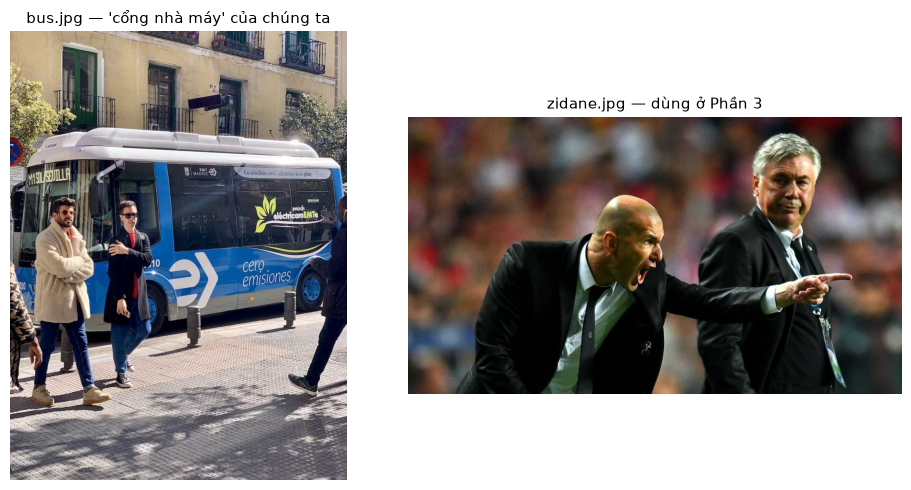

In [5]:
img_bus, img_zidane = read_image(IMG_BUS), read_image(IMG_ZIDANE)        # torch.uint8, (3, H, W), RGB
print("bus.jpg:", tuple(img_bus.shape), "| zidane.jpg:", tuple(img_zidane.shape))
show(img_bus, img_zidane, titles=["bus.jpg — 'cổng nhà máy' của chúng ta", "zidane.jpg — dùng ở Phần 3"])

---
## Phần 1 — Object Detection (35')
🏭 **Mảnh ghép 1: đếm người ở cổng.** Detector trả về một *tập* box có kích thước không biết trước. Để đếm đúng, mỗi người phải ứng với **đúng một** box, và đó là việc của NMS (hoặc của head one-to-one).

### 1A. Đọc output của detector như một tensor — 7'
Chạy 3 ô dưới và chú ý **shape**. Chưa cần code gì.

Output của 1 ảnh: {'boxes': (29, 4), 'labels': (29,), 'scores': (29,)}  ← N × (box xyxy, class, score)


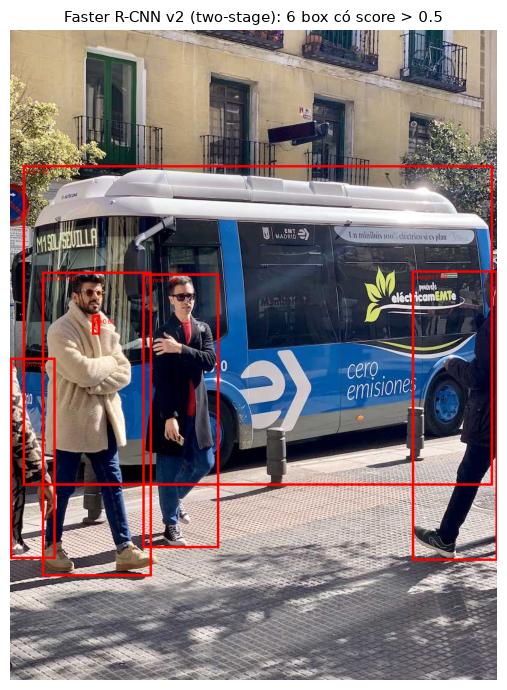

Hai lần NMS bên trong model: RPN (IoU 0.7, giữ 1000 proposal) → RoI head (IoU 0.5, score ≥ 0.05)


In [6]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2

w_det = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT                # COCO box AP 46.7
frcnn = fasterrcnn_resnet50_fpn_v2(weights=w_det).eval().to(DEVICE)
COCO_TV = w_det.meta["categories"]                                 # 91 tên class của torchvision

with torch.inference_mode():
    out = frcnn([w_det.transforms()(img_bus).to(DEVICE)])[0]       # vào: list ảnh float [0,1] · ra: list dict
out = {k: v.cpu() for k, v in out.items()}
print("Output của 1 ảnh:", {k: tuple(v.shape) for k, v in out.items()}, " ← N × (box xyxy, class, score)")

keep = out["scores"] > 0.5
frcnn_boxes, frcnn_labels, frcnn_scores = out["boxes"][keep], out["labels"][keep], out["scores"][keep]
tags = [f"{COCO_TV[c]} {s:.2f}" for c, s in zip(frcnn_labels, frcnn_scores)]
show(draw_bounding_boxes(img_bus, frcnn_boxes, tags, width=4, colors="red", font_size=26),
     titles=[f"Faster R-CNN v2 (two-stage): {int(keep.sum())} box có score > 0.5"], size=7)
print(f"Hai lần NMS bên trong model: RPN (IoU {frcnn.rpn.nms_thresh}, giữ {frcnn.rpn.post_nms_top_n()} proposal) "
      f"→ RoI head (IoU {frcnn.roi_heads.nms_thresh}, score ≥ {frcnn.roi_heads.score_thresh})")

🔮 **Dự đoán.** YOLO26 dự đoán trên 3 tầng feature có stride 8, 16, 32, mỗi vị trí một dự đoán.
Với ảnh vào 640×640 thì có bao nhiêu dự đoán thô? Còn với `bus.jpg` sau khi letterbox về 640×480? Nhẩm xong rồi chạy ô dưới.

In [7]:
from ultralytics.data.augment import LetterBox

yolo = YOLO("yolo26n.pt")
NAMES = yolo.names
net = yolo.model.eval()                                            # nn.Module nằm bên trong


def raw_forward(h, w):
    """Cho một ảnh rỗng (h, w) đi qua mạng, trả về output thô trước mọi bước lọc."""
    x = torch.zeros(1, 3, h, w, device=next(net.parameters()).device)
    with torch.inference_mode():
        decoded, heads = net(x)
    return decoded, heads


decoded, heads = raw_forward(640, 640)
print("640×640 →", tuple(decoded.shape), "= (batch, 4 toạ độ + 80 class, số dự đoán)")
for name in ("one2many", "one2one"):
    print(f"   head {name}: boxes {tuple(heads[name]['boxes'].shape)} · scores {tuple(heads[name]['scores'].shape)}"
          f" · lưới 3 tầng {[tuple(f.shape[-2:]) for f in heads[name]['feats']]}")

lb = LetterBox((640, 640), auto=True, stride=32)(image=cv2.imread(IMG_BUS))
print(f"bus.jpg {tuple(img_bus.shape[-2:])} → letterbox {lb.shape[:2]} →", tuple(raw_forward(*lb.shape[:2])[0].shape))

640×640 → (1, 84, 8400) = (batch, 4 toạ độ + 80 class, số dự đoán)
   head one2many: boxes (1, 4, 8400) · scores (1, 80, 8400) · lưới 3 tầng [(80, 80), (40, 40), (20, 20)]
   head one2one: boxes (1, 4, 8400) · scores (1, 80, 8400) · lưới 3 tầng [(80, 80), (40, 40), (20, 20)]


bus.jpg (1080, 810) → letterbox (640, 480) → (1, 84, 6300)


**Box 'person' trên ảnh 810×1080**

| Quy ước | Giá trị |
|---|---|
| xyxy — torchvision, Pascal VOC | [53, 402, 236, 908] |
| xywh — COCO json | [53, 402, 182, 506] |
| cxcywh chuẩn hoá — YOLO .txt | [0.178, 0.606, 0.225, 0.468] |

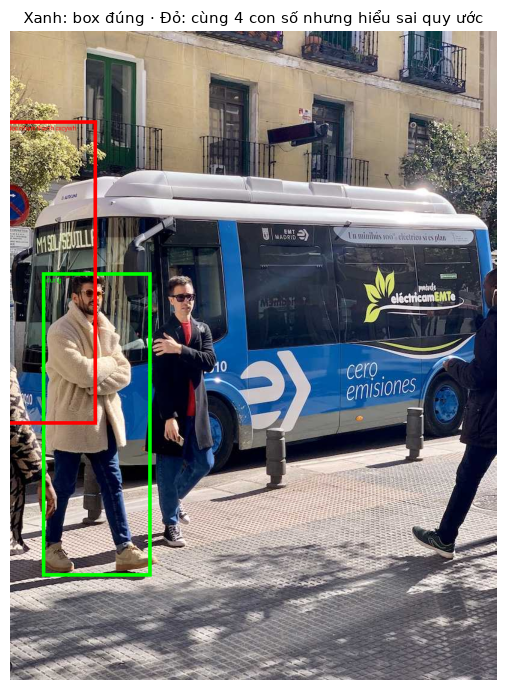

In [8]:
# Một box, ba cách viết — và bug kinh điển khi nhầm chúng
H, W = img_bus.shape[-2:]
x1, y1, x2, y2 = frcnn_boxes[0].tolist()                           # box điểm cao nhất, dạng xyxy
xywh = [x1, y1, x2 - x1, y2 - y1]                                  # COCO json: góc trên-trái + kích thước (pixel)
cxcywh_n = [(x1 + x2) / 2 / W, (y1 + y2) / 2 / H, (x2 - x1) / W, (y2 - y1) / H]   # nhãn YOLO .txt: tâm + kích thước, chia cho W, H
show_table([
    {"Quy ước": "xyxy — torchvision, Pascal VOC", "Giá trị": str([round(v) for v in (x1, y1, x2, y2)])},
    {"Quy ước": "xywh — COCO json", "Giá trị": str([round(v) for v in xywh])},
    {"Quy ước": "cxcywh chuẩn hoá — YOLO .txt", "Giá trị": str([round(v, 3) for v in cxcywh_n])},
], title=f"Box '{COCO_TV[frcnn_labels[0]]}' trên ảnh {W}×{H}")

bx, by, bw, bh = xywh                                              # dữ liệu là xywh ...
wrong = [bx - bw / 2, by - bh / 2, bx + bw / 2, by + bh / 2]       # ... nhưng bị đọc như thể (bx, by) là TÂM
show(draw_bounding_boxes(img_bus, torch.tensor([[x1, y1, x2, y2], wrong]), ["dung", "xywh doc nham thanh cxcywh"],
                         colors=["lime", "red"], width=6, font_size=26),
     titles=["Xanh: box đúng · Đỏ: cùng 4 con số nhưng hiểu sai quy ước"], size=7)

❓ **Q1.** (a) `bus.jpg` sau letterbox là 640×480. Có bao nhiêu dự đoán thô, và vì sao ít hơn 8 400?
(b) Bạn nhận một file nhãn mà khi vẽ lên ảnh, mọi box đều lệch sang **phải và xuống dưới** đúng nửa kích thước của nó. Nhãn gốc ở quy ước nào và đã bị đọc như quy ước nào?

In [9]:
Q1 = """
(a) bus.jpg cho 6.300 dự đoán thô: ba lưới 80×60, 40×30 và 20×15 có tổng 6.300 vị trí. Con số này nhỏ hơn 8.400 vì letterbox giữ tỉ lệ ảnh thành 640×480 thay vì lưới 640×640.
(b) Nhãn gốc là cxcywh nhưng bị đọc nhầm thành xywh với x, y là góc trên-trái. Vì tâm bị dùng làm góc nên box dịch sang phải và xuống dưới đúng nửa kích thước.
"""

### 1B. 🧩 Tự cài đặt IoU và NMS — 15'

$$\mathrm{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}=\frac{|A\cap B|}{|A|+|B|-|A\cap B|}$$

Ví dụ dùng suốt mục này — ba box dạng `xyxy`:

| Box | Toạ độ | Diện tích |
|---|---|---|
| A | (0, 0, 10, 10) | 100 |
| B | (5, 0, 15, 10) | 100 |
| C | (20, 20, 30, 30) | 100 |

🔮 **Dự đoán.** IoU(A, B) = ? IoU(A, C) = ? (A và B chồng nhau một dải rộng 5, cao 10.)

**Bước 1/3 — `box_iou`.** Điền 4 chỗ `...`. Không dùng `torchvision.ops`.

In [10]:
def box_iou(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """a: (N,4), b: (M,4), định dạng xyxy → ma trận IoU (N,M)."""
    # Bước 1 — diện tích từng box = (x2 − x1) · (y2 − y1)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])            # (N,)
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])            # (M,)   🧩
    # Bước 2 — hình chữ nhật giao: góc trên-trái lấy max, góc dưới-phải lấy min.
    #          a[:, None, :2] có shape (N,1,2), b[None, :, :2] có shape (1,M,2) → broadcast thành (N,M,2)
    lt = torch.max(a[:, None, :2], b[None, :, :2])                # (N,M,2)
    rb = torch.min(a[:, None, 2:], b[None, :, 2:])                # (N,M,2) 🧩
    # Bước 3 — (rộng, cao) của phần giao. Hai box không chạm nhau thì phải ra 0, không được âm.
    wh = (rb - lt).clamp(min=0)                                   # (N,M,2) 🧩
    inter = wh[..., 0] * wh[..., 1]                               # (N,M)
    # Bước 4 — IoU = giao / hợp, với hợp = |A| + |B| − giao
    return inter / (area_a[:, None] + area_b[None, :] - inter).clamp(min=1e-9)  # 🧩


check_box_iou()

✅ box_iou đạt (5 phép thử)


<details><summary>💡 Gợi ý 1 — Bước 1 và 2</summary>

`area_b` viết y hệt `area_a`, đổi `a` thành `b`. `rb` viết y hệt `lt`, đổi `torch.max` thành `torch.min` và `:2` thành `2:`.
</details>
<details><summary>💡 Gợi ý 2 — Bước 3</summary>

`(rb - lt)` cho (rộng, cao). Khi hai box rời nhau, cả hai số đều âm và tích của chúng lại dương. Chặn bằng `.clamp(min=0)`.
</details>
<details><summary>💡 Gợi ý 3 — Bước 4</summary>

`area_a` có shape (N,), `area_b` có shape (M,). Để cộng thành (N,M): `area_a[:, None] + area_b[None, :]`. Rồi trừ `inter` và lấy `inter / (...)`.
</details>

**Bước 2/3 — `nms`.** Greedy NMS: giữ box điểm cao nhất, loại mọi box còn lại có IoU **>** ngưỡng với nó, lặp lại.

🔮 **Dự đoán.** Với score A = 0.9, B = 0.8, C = 0.7: ngưỡng 0.3 giữ những box nào? Ngưỡng 0.5 thì sao?

In [11]:
def nms(boxes: torch.Tensor, scores: torch.Tensor, iou_thr: float = 0.5) -> torch.Tensor:
    """Greedy NMS. Trả về chỉ số (LongTensor) các box được giữ, theo thứ tự score giảm dần."""
    order = scores.argsort(descending=True)                       # chỉ số box, điểm cao → thấp
    keep = []
    while order.numel() > 0:
        i = order[0]                                              # box điểm cao nhất còn lại → giữ
        keep.append(int(i))
        assert len(keep) <= len(boxes), "order không ngắn lại → vòng lặp vô hạn. Xem lại Bước 2."
        rest = order[1:]                                          # chỉ số các box còn lại
        # Bước 1 — IoU giữa box i và từng box trong rest. Dùng box_iou của bạn; boxes[i][None] có shape (1,4).
        ious = box_iou(boxes[i][None], boxes[rest])[0]            # (len(rest),)  🧩
        # Bước 2 — chỉ giữ lại trong hàng chờ những box có IoU <= iou_thr (IoU > ngưỡng nghĩa là duplicate của box i)
        order = rest[ious <= iou_thr]                             # 🧩
    return torch.tensor(keep, dtype=torch.long)


check_nms()

✅ nms đạt (6 phép thử)


<details><summary>💡 Gợi ý — <code>nms</code></summary>

Bước 1: `box_iou(boxes[i][None], boxes[rest])` trả về ma trận (1, len(rest)); lấy hàng đầu bằng `[0]`.
Bước 2: `rest[ious <= iou_thr]` — dùng mask boolean để lọc chính `rest`.
</details>

**Bước 3/3 — `batched_nms`.** Người đứng trước xe buýt có IoU cao với xe buýt nhưng **không** phải duplicate. NMS chỉ nên so các box *cùng class*.
Mẹo: dịch toàn bộ box của class `c` đi một đoạn `c × (toạ độ lớn nhất + 1)`. Khi đó box khác class không bao giờ chạm nhau, và chỉ cần gọi `nms` thường một lần.

In [12]:
def batched_nms(boxes: torch.Tensor, scores: torch.Tensor, classes: torch.Tensor, iou_thr: float = 0.5) -> torch.Tensor:
    """Class-aware NMS: chỉ loại duplicate giữa các box CÙNG class."""
    # Bước 1 — độ dịch của từng box: class id × (toạ độ lớn nhất + 1). classes.to(boxes) đổi class id sang cùng kiểu float.
    offset = classes.to(boxes) * (boxes.max() + 1)                # (N,)  🧩
    # Bước 2 — cộng offset vào cả 4 toạ độ (offset[:, None] có shape (N,1)) rồi gọi nms của bạn
    return nms(boxes + offset[:, None], scores, iou_thr)          # 🧩


check_batched_nms()

✅ batched_nms đạt (4 phép thử)


<details><summary>💡 Gợi ý — <code>batched_nms</code></summary>

`offset = classes.to(boxes) * (boxes.max() + 1)`, rồi `return nms(boxes + offset[:, None], scores, iou_thr)`.
Chỉ số trả về vẫn là chỉ số của `boxes` gốc vì ta không đổi thứ tự, chỉ dịch toạ độ.
</details>

In [13]:
gate("1B")        # 🚦 hết 15 phút mà chưa xong? → gate("1B", lifeline=True)

✅ Mục 1B xong: box_iou, nms, batched_nms. Đi tiếp!


### 1C. YOLO26: one-to-many + NMS và one-to-one (NMS-free) — 8'
YOLO26 train **hai head** trên cùng backbone:
- **one-to-many**: mỗi object được gán cho nhiều vị trí → tín hiệu học dày, nhưng output có duplicate → **cần NMS**;
- **one-to-one**: mỗi object đúng một dự đoán (như Hungarian matching của DETR) → **không cần NMS**.

Trong Ultralytics: mặc định dùng one-to-many + NMS, còn `nms=False` chuyển sang head one-to-one. Đặt `iou=1.0` thì NMS gần như không loại box nào, nên ta nhìn thấy duplicate.
Ta dùng **hai object riêng** (`yolo` và `yolo_e2e`) vì một object đã chuyển sang `nms=False` sẽ giữ nguyên head one-to-one cho các lần gọi sau.

🔮 **Dự đoán.** Ảnh có 4 người và 1 xe buýt. Head one-to-many ở conf ≥ 0.25 sẽ cho khoảng bao nhiêu box trước NMS: 5, 15, hay 50?

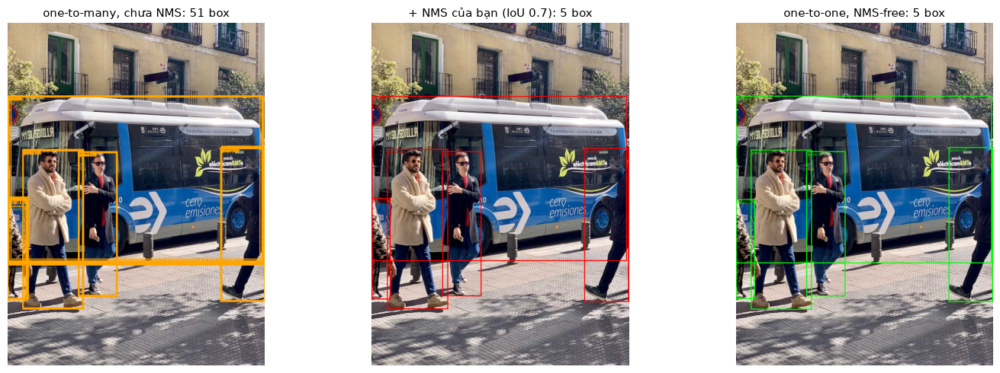

NMS của bạn giữ 5 box · NMS của Ultralytics giữ 5 box ✅ khớp
🏭 Camera cổng đếm được: 4 người, 1 xe buýt.


In [14]:
CONF = 0.25
yolo_e2e = YOLO("yolo26n.pt")                                            # cùng weights, nhưng luôn gọi với nms=False
r_raw = yolo.predict(IMG_BUS, conf=CONF, iou=1.0, verbose=False)[0]      # one-to-many, NMS gần như tắt
r_nms = yolo.predict(IMG_BUS, conf=CONF, iou=0.7, verbose=False)[0]      # one-to-many + NMS của Ultralytics
r_e2e = yolo_e2e.predict(IMG_BUS, conf=CONF, nms=False, verbose=False)[0]   # one-to-one, không NMS

b, s, c = r_raw.boxes.xyxy.cpu(), r_raw.boxes.conf.cpu(), r_raw.boxes.cls.cpu()
keep_mine = batched_nms(b, s, c, iou_thr=0.7)                            # ← NMS của BẠN

show(draw_det(img_bus, b, c, s, "orange", NAMES),
     draw_det(img_bus, b[keep_mine], c[keep_mine], s[keep_mine], "red", NAMES),
     draw_det(img_bus, r_e2e.boxes.xyxy.cpu(), r_e2e.boxes.cls.cpu(), r_e2e.boxes.conf.cpu(), "lime", NAMES),
     titles=[f"one-to-many, chưa NMS: {len(b)} box", f"+ NMS của bạn (IoU 0.7): {len(keep_mine)} box",
             f"one-to-one, NMS-free: {len(r_e2e.boxes)} box"])
print(f"NMS của bạn giữ {len(keep_mine)} box · NMS của Ultralytics giữ {len(r_nms.boxes)} box", "✅ khớp" if len(keep_mine) == len(r_nms.boxes) else "❌ lệch — xem lại 1B")
print(f"🏭 Camera cổng đếm được: {int((r_e2e.boxes.cls == 0).sum())} người, {int((r_e2e.boxes.cls == 5).sum())} xe buýt.")

Giờ đo **latency từng giai đoạn** ở hai mức confidence: 0.25 (lúc triển khai) và 0.001 (lúc tính mAP).

🔮 **Dự đoán.** Cột nào (preprocess, inference, postprocess) sẽ khác nhau nhiều nhất giữa hai head? Ở mức conf nào?

In [15]:
def bench(model, n=30, **kw):
    """Thời gian trung bình (ms) của từng giai đoạn trên bus.jpg, lấy từ Results.speed."""
    model.predict(IMG_BUS, verbose=False, **kw)                          # warm-up
    acc = {"preprocess": 0.0, "inference": 0.0, "postprocess": 0.0}
    for _ in range(n):
        r = model.predict(IMG_BUS, verbose=False, **kw)[0]
        for k in acc:
            acc[k] += r.speed[k] / n
    return {f"{k} (ms)": round(v, 2) for k, v in acc.items()} | {"số box": len(r.boxes)}


LATENCY = [
    {"Cấu hình": "one-to-many + NMS, conf 0.25"} | bench(yolo, conf=0.25, iou=0.7),
    {"Cấu hình": "one-to-many + NMS, conf 0.001"} | bench(yolo, conf=0.001, iou=0.7),
    {"Cấu hình": "one-to-one NMS-free, conf 0.25"} | bench(yolo_e2e, conf=0.25, nms=False),
    {"Cấu hình": "one-to-one NMS-free, conf 0.001"} | bench(yolo_e2e, conf=0.001, nms=False),
]
show_table(LATENCY, title=f"Latency YOLO26n trên {DEVICE} (trung bình 30 lần)")

**Latency YOLO26n trên cuda (trung bình 30 lần)**

| Cấu hình | preprocess (ms) | inference (ms) | postprocess (ms) | số box |
|---|---|---|---|---|
| one-to-many + NMS, conf 0.25 | 1.370 | 7.580 | 1.500 | 5 |
| one-to-many + NMS, conf 0.001 | 1.320 | 6.770 | 1.620 | 202 |
| one-to-one NMS-free, conf 0.25 | 1.350 | 7.260 | 0.640 | 5 |
| one-to-one NMS-free, conf 0.001 | 1.300 | 7.490 | 0.660 | 204 |

❓ **Q2.** Nhìn vào bảng của bạn: cột nào thay đổi nhiều nhất giữa hai head, và ở mức conf nào? Giải thích vì sao lợi ích của NMS-free rõ hơn khi conf thấp, khi cảnh đông, và khi chạy trên CPU/NPU.

In [16]:
Q2 = """
Cột thay đổi rõ nhất là postprocess: one-to-many + NMS mất 1,63 ms, còn one-to-one chỉ 0,63 ms, giảm khoảng 1,00 ms (61%) ở cả hai mức conf. Ở conf=0,001, model phải xử lý khoảng 202–204 box nên lợi ích kiến trúc của NMS-free có ý nghĩa hơn khi số candidate tăng.
Cảnh đông và conf thấp làm chi phí so sánh/chọn box của NMS tăng nhanh; trên CPU/NPU, phần hậu xử lý này không được GPU che khuất nên bỏ NMS giúp latency ổn định hơn.
"""

❓ **Q3.** (a) Hai công nhân đứng sát nhau, hai box có IoU 0.75. Với NMS ngưỡng 0.7 chuyện gì xảy ra? Tăng hoặc giảm ngưỡng thì đánh đổi điều gì?
(b) Head one-to-one không cần NMS. Vì sao YOLO26 vẫn train thêm head one-to-many?

In [17]:
Q3 = """
(a) Với IoU=0,75 và ngưỡng NMS=0,7, box có score thấp hơn của một công nhân sẽ bị loại, gây đếm thiếu. Tăng ngưỡng giữ được các object đứng sát nhau nhưng dễ sót duplicate; giảm ngưỡng dọn duplicate mạnh hơn nhưng dễ gộp nhầm hai object.
(b) Head one-to-many tạo nhiều positive assignment cho mỗi ground truth, cung cấp tín hiệu huấn luyện dày và ổn định hơn. Nó hỗ trợ head one-to-one học đặc trưng tốt, còn khi suy luận chỉ cần head one-to-one NMS-free.
"""

### 1D. ⭐ Tự tính AP (COCO 101 điểm) — làm nếu còn thời gian
Dùng đúng ví dụ trên slide *"Từ đường PR đến AP"*: **10 ground-truth, 15 dự đoán** đã xếp theo confidence, với chuỗi đúng/sai
`T T F T F T T F F T F T F F F`. Slide ghi AP = 0.535.

In [18]:
def average_precision(tp: np.ndarray, conf: np.ndarray, n_gt: int) -> float:
    """AP kiểu COCO. tp[i] = 1 nếu dự đoán i là TP, 0 nếu FP · conf[i]: confidence · n_gt: số ground-truth."""
    tp = tp[np.argsort(-conf)]                                    # sắp theo confidence giảm dần
    ctp, cfp = np.cumsum(tp), np.cumsum(1 - tp)                   # TP và FP cộng dồn
    # Bước 1 — precision và recall tại từng vị trí trong danh sách
    recall = ctp / n_gt                                           # 🧩 TP cộng dồn / số GT
    precision = ctp / np.arange(1, len(ctp) + 1)                  # 🧩 TP cộng dồn / số dự đoán đã xét
    # Bước 2 — envelope: p(r) = precision lớn nhất ở mọi recall ≥ r (quét từ phải sang trái)
    envelope = np.maximum.accumulate(precision[::-1])[::-1]       # 🧩 gợi ý: np.maximum.accumulate trên mảng đảo ngược
    # Bước 3 (viết sẵn) — lấy mẫu 101 mức recall; mỗi mức lấy envelope tại vị trí đầu tiên có recall ≥ mức đó (không có → 0)
    ap = 0.0
    for r in np.linspace(0, 1, 101):
        idx = np.searchsorted(recall, r, side="left")
        ap += envelope[idx] if idx < len(envelope) else 0.0
    return ap / 101


check_average_precision()

✅ average_precision đạt (4 phép thử)


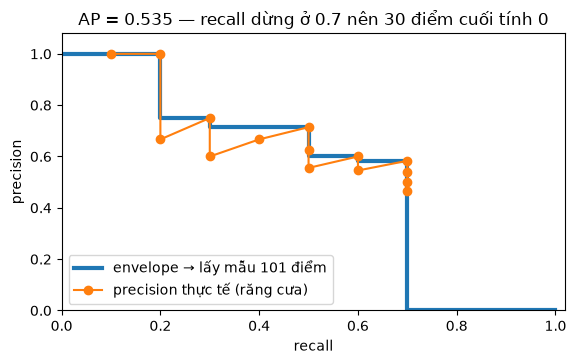

In [19]:
if PROGRESS.get("average_precision") == "ok":
    tp_slide = np.array([1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0]); conf_slide = np.linspace(0.95, 0.25, 15)
    rec = np.cumsum(tp_slide) / 10; prec = np.cumsum(tp_slide) / np.arange(1, 16)
    env = np.maximum.accumulate(prec[::-1])[::-1]
    plt.figure(figsize=(6.5, 3.6))
    plt.step(np.r_[0, rec, rec[-1], 1], np.r_[env[0], env, 0, 0], where="pre", lw=3, label="envelope → lấy mẫu 101 điểm")
    plt.plot(rec, prec, "o-", color="tab:orange", label="precision thực tế (răng cưa)")
    plt.xlabel("recall"); plt.ylabel("precision"); plt.xlim(0, 1.02); plt.ylim(0, 1.08); plt.legend(loc="lower left")
    plt.title(f"AP = {average_precision(tp_slide, conf_slide, 10):.3f} — recall dừng ở 0.7 nên 30 điểm cuối tính 0"); plt.show()
else:
    print("(bỏ qua hình PR — average_precision chưa đạt; đây là phần ⭐ không bắt buộc)")

---
## Phần 2 — Segmentation (30')
🏭 **Mảnh ghép 2: tạo nhãn cho class mới.** COCO không có class "mũ bảo hộ". Muốn fine-tune thì phải có nhãn, mà vẽ tay một mask polygon mất khoảng 80 giây.
Phần này dựng pipeline **detector → SAM → polygon** để máy gán nhãn thay người.

### 2A. Semantic và instance trên cùng một ảnh — 8'
- **Semantic** (YOLO26n-sem, train trên Cityscapes, 19 class): mỗi *pixel* một class.
- **Instance** (Mask R-CNN v2): mỗi *object* một mask riêng.

🔮 **Dự đoán.** Ảnh có 4 người. Nếu lấy bản đồ semantic của class `person` rồi đếm số vùng liên thông, bạn sẽ đếm được mấy "người"?

Semantic : (1080, 810) — tỉ lệ pixel: {'road': '28%', 'sidewalk': '2%', 'building': '19%', 'vegetation': '5%', 'person': '15%', 'train': '31%'}


Instance : (22, 1, 1080, 810) → giữ score > 0.5 → (5, 1080, 810) ['person', 'bus', 'person', 'person', 'person']


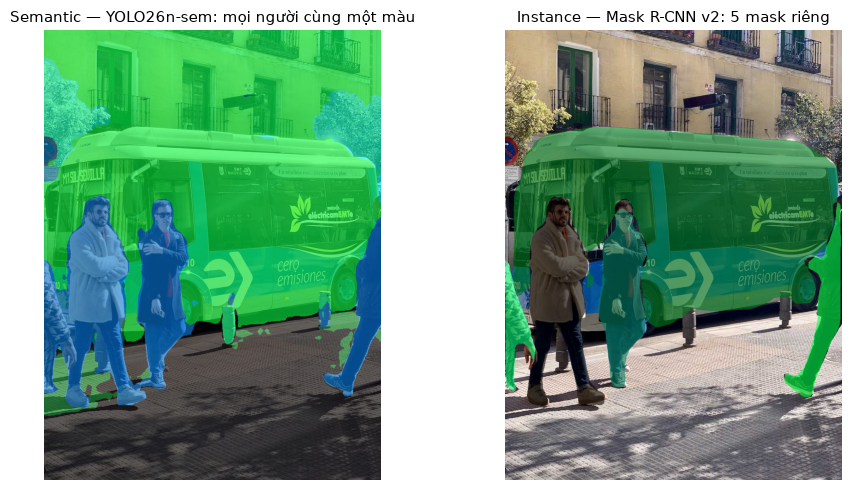

In [20]:
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2

# --- Semantic: mỗi pixel một class ---
yolo_sem = YOLO("yolo26n-sem.pt")
r_sem = yolo_sem.predict(IMG_BUS, verbose=False)[0]
sem = r_sem.semantic_mask.data.cpu().long()                       # (H, W): class id của từng pixel
SEM_NAMES = yolo_sem.names
sem_ids = sem.unique().tolist()
print("Semantic :", tuple(sem.shape), "— tỉ lệ pixel:",
      {SEM_NAMES[k]: f"{(sem == k).float().mean():.0%}" for k in sem_ids if (sem == k).float().mean() > 0.01})

# --- Instance: mỗi object một mask ---
w_ins = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT                  # COCO box AP 47.4 / mask AP 41.8
mrcnn = maskrcnn_resnet50_fpn_v2(weights=w_ins).eval().to(DEVICE)
with torch.inference_mode():
    o = mrcnn([w_ins.transforms()(img_bus).to(DEVICE)])[0]
o = {k: v.cpu() for k, v in o.items()}
keep = o["scores"] > 0.5
masks_mrcnn = o["masks"][keep, 0] > 0.5                           # (N,1,H,W) xác suất → (N,H,W) bool
labels_mrcnn = o["labels"][keep]
print("Instance :", tuple(o["masks"].shape), "→ giữ score > 0.5 →", tuple(masks_mrcnn.shape), [COCO_TV[c] for c in labels_mrcnn])

show(draw_segmentation_masks(img_bus, torch.stack([sem == k for k in sem_ids]), alpha=0.6),
     draw_segmentation_masks(img_bus, masks_mrcnn, alpha=0.6),
     titles=["Semantic — YOLO26n-sem: mọi người cùng một màu", f"Instance — Mask R-CNN v2: {len(masks_mrcnn)} mask riêng"])

Vùng liên thông của class 'person': 8 vùng, diện tích (pixel): [106181, 20309, 1241, 17, 8, 4, 4, 3]
Mask R-CNN: 4 người · Thực tế: 4 người
Bên trong box 'bus' của detector, semantic nói: {'road': '5%', 'vegetation': '3%', 'person': '23%', 'train': '63%'}


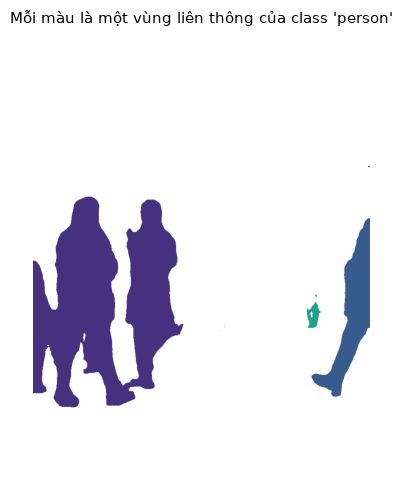

In [21]:
# Đếm người bằng bản đồ semantic có được không?
person_id = next(k for k, v in SEM_NAMES.items() if v == "person")
n_cc, cc, stats, _ = cv2.connectedComponentsWithStats((sem == person_id).numpy().astype(np.uint8))
n_inst = int((labels_mrcnn == COCO_TV.index("person")).sum())
print(f"Vùng liên thông của class 'person': {n_cc - 1} vùng, diện tích (pixel): {sorted(stats[1:, cv2.CC_STAT_AREA].tolist(), reverse=True)}")
print(f"Mask R-CNN: {n_inst} người · Thực tế: 4 người")

# Xe buýt được gán class gì?
bx1, by1, bx2, by2 = r_e2e.boxes.xyxy[r_e2e.boxes.cls == 5][0].int().tolist()
ids, cnt = sem[by1:by2, bx1:bx2].unique(return_counts=True)
print("Bên trong box 'bus' của detector, semantic nói:", {SEM_NAMES[int(i)]: f"{int(n) / int(cnt.sum()):.0%}" for i, n in zip(ids, cnt) if n / cnt.sum() > 0.03})
show(np.ma.masked_equal(cc, 0), titles=["Mỗi màu là một vùng liên thông của class 'person'"], size=5)

❓ **Q4.** (a) Vì sao đếm vùng liên thông trên bản đồ semantic cho ra số người sai — nêu một nguyên nhân gây đếm **thiếu** và một nguyên nhân gây đếm **thừa**. Panoptic segmentation giải quyết việc này thế nào?
(b) Bản đồ semantic gán xe buýt vào class nào? Vì sao model lại nhầm như vậy?

In [22]:
Q4 = """
(a) Hai người chạm nhau có thể dính thành một vùng nên đếm thiếu; ngược lại mask bị vỡ hoặc có nhiễu đốm nhỏ sẽ đếm thừa. Kết quả thực tế có 8 vùng person nhưng chỉ 4 người; panoptic segmentation gán thêm instance ID cho các class thing trong khi vẫn giữ nhãn semantic cho stuff.
(b) Bên trong box xe buýt, 63% pixel bị gán thành train. Hình dáng phương tiện lớn, cửa sổ và ngữ cảnh không điển hình khiến model semantic nhầm với class train.
"""

### 2B. 🧩 Mask IoU và chuyển đổi polygon ↔ mask — 10'
Ba hàm "data engineering" bạn sẽ dùng mỗi khi đánh giá model segmentation hoặc tạo nhãn.

**Bước 1/3 — `mask_iou`.** Với mask nhị phân, *giao* chính là số pixel cùng bằng 1, tức là **tích vô hướng** của hai vector 0/1.
Vì vậy một phép nhân ma trận cho ra cả bảng giao (N, M).

🔮 **Dự đoán.** Hai hình vuông 50×50, lệch nhau 25 pixel theo cả hai chiều. Giao = ? Hợp = ? IoU = ?

In [23]:
def mask_iou(m1: torch.Tensor, m2: torch.Tensor) -> torch.Tensor:
    """m1: (N,H,W) bool, m2: (M,H,W) bool → ma trận IoU (N,M)."""
    # Bước 1 — duỗi mỗi mask thành một vector 0/1 dài H·W
    a = m1.flatten(1).float()                                     # (N, H·W)
    b = m2.flatten(1).float()                                     # (M, H·W)  🧩
    # Bước 2 — bảng giao (N,M) bằng một phép nhân ma trận
    inter = a @ b.T                                               # (N,M)  🧩
    # Bước 3 — diện tích mỗi mask = tổng theo hàng; hợp = |A| + |B| − giao (nhớ broadcast như ở box_iou)
    area_a, area_b = a.sum(1), b.sum(1)
    union = area_a[:, None] + area_b[None, :] - inter             # (N,M)  🧩
    return inter / union.clamp(min=1e-9)


check_mask_iou()

✅ mask_iou đạt (4 phép thử)


<details><summary>💡 Gợi ý — <code>mask_iou</code></summary>

`b` viết như `a`. `inter = a @ b.T` (ma trận (N, H·W) nhân (H·W, M)). `union = area_a[:, None] + area_b[None, :] - inter`.
</details>

**Bước 2/3 — `polygon_to_mask`** và **Bước 3/3 — `mask_to_yolo_seg`.** Nhãn YOLO-seg mỗi dòng là `class x1 y1 x2 y2 … xn yn`,
toạ độ đỉnh polygon **chuẩn hoá về [0, 1]** (x chia cho W, y chia cho H). Mỗi hàm chỉ cần điền 1–2 dòng.

In [24]:
def polygon_to_mask(poly: np.ndarray, h: int, w: int) -> np.ndarray:
    """poly: (K,2) toạ độ pixel (x, y) → mask bool (H,W)."""
    mask = np.zeros((h, w), dtype=np.uint8)
    pts = np.round(poly).astype(np.int32)                         # cv2 cần toạ độ nguyên
    # Tô kín đa giác bằng giá trị 1: cv2.fillPoly(ảnh, [danh sách đỉnh], màu)
    cv2.fillPoly(mask, [pts], 1)                                  # 🧩
    return mask.astype(bool)


def mask_to_yolo_seg(mask: np.ndarray, cls_id: int, simplify: float = 0.002) -> str:
    """mask bool (H,W) → 1 dòng nhãn YOLO-seg 'class x1 y1 x2 y2 ...' (toạ độ chuẩn hoá)."""
    h, w = mask.shape
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return ""
    # Bước 1 — mask có thể vỡ thành nhiều mảnh: lấy contour có DIỆN TÍCH lớn nhất (cv2.contourArea)
    cnt = max(contours, key=cv2.contourArea)                      # 🧩
    # Bước 2 (viết sẵn) — bỏ bớt đỉnh thừa
    cnt = cv2.approxPolyDP(cnt, simplify * cv2.arcLength(cnt, True), True).reshape(-1, 2)     # (K,2) pixel (x, y)
    if len(cnt) < 3:
        return ""
    # Bước 3 — chuẩn hoá về [0, 1]: x chia cho W, y chia cho H
    norm = cnt / np.array([w, h])                                 # (K,2)  🧩
    return f"{cls_id} " + " ".join(f"{v:.6f}" for v in norm.flatten())


check_polygon_to_mask()
check_mask_to_yolo_seg()

✅ polygon_to_mask đạt (2 phép thử)
✅ mask_to_yolo_seg đạt (4 phép thử)


<details><summary>💡 Gợi ý — polygon ↔ mask</summary>

`polygon_to_mask`: `cv2.fillPoly(mask, [pts], 1)`.
`mask_to_yolo_seg`: `cnt = max(contours, key=cv2.contourArea)` và `norm = cnt / np.array([w, h])` (cột 0 là x, cột 1 là y).
</details>

In [25]:
gate("2B")        # 🚦 hết 10 phút mà chưa xong? → gate("2B", lifeline=True)

✅ Mục 2B xong: mask_iou, polygon_to_mask, mask_to_yolo_seg. Đi tiếp!


**Ghép cặp bằng Hungarian matching**

| YOLO26n-seg | Mask R-CNN v2 | mask IoU |
|---|---|---|
| #0 person | #0 person | 0.939 |
| #1 person | #2 person | 0.842 |
| #2 bus | #1 bus | 0.933 |
| #3 person | #3 person | 0.921 |
| #4 person | #4 person | 0.890 |

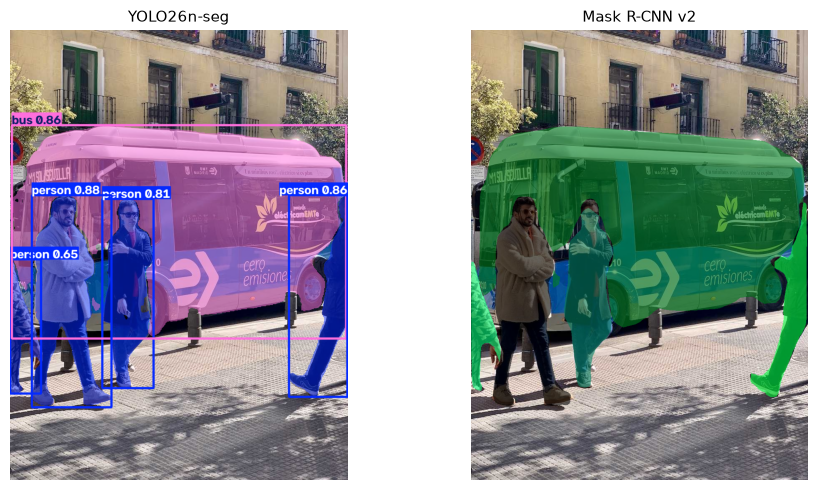

In [26]:
# Áp dụng: mask của YOLO26n-seg giống mask của Mask R-CNN đến đâu? Ghép cặp bằng Hungarian matching (như DETR).
yolo_seg = YOLO("yolo26n-seg.pt")
rs = yolo_seg.predict(IMG_BUS, conf=0.25, verbose=False)[0]
H, W = img_bus.shape[-2:]
masks_yolo = torch.from_numpy(np.stack([polygon_to_mask(p, H, W) for p in rs.masks.xy]))     # polygon của YOLO → mask
iou_mat = mask_iou(masks_yolo, masks_mrcnn)                                                # (số mask YOLO, số mask Mask R-CNN)
ri, ci = linear_sum_assignment(-iou_mat.numpy())                                           # ghép 1–1 sao cho tổng IoU lớn nhất
show_table([{"YOLO26n-seg": f"#{i} {NAMES[int(rs.boxes.cls[i])]}", "Mask R-CNN v2": f"#{j} {COCO_TV[labels_mrcnn[j]]}",
             "mask IoU": float(iou_mat[i, j])} for i, j in zip(ri, ci)], title="Ghép cặp bằng Hungarian matching")
show(bgr_to_u8(rs.plot()), draw_segmentation_masks(img_bus, masks_mrcnn, alpha=0.6), titles=["YOLO26n-seg", "Mask R-CNN v2"])

❓ **Q5.** (a) YOLO26-seg tạo mask bằng *32 prototype dùng chung × hệ số riêng của từng object*, còn Mask R-CNN dự đoán một mask 28×28 cho từng RoI. Mỗi cách cho biên mask thô ở object **lớn** hay **nhỏ**, vì sao?
(b) Ô trên ghép cặp bằng Hungarian matching. Nếu thay bằng "mỗi mask YOLO lấy mask Mask R-CNN có IoU cao nhất" thì có thể sai ở đâu?

In [27]:
Q5 = """
(a) YOLO26-seg dùng lưới prototype chung nên object nhỏ/mỏng dễ mất chi tiết khi độ phân giải không gian và số basis bị giới hạn. Mask R-CNN cố định mask 28×28 cho mỗi RoI, nên khi phóng mask lên object lớn thì biên dễ bị thô; trong lần chạy này IoU cặp mask nằm trong 0,842–0,939.
(b) Ghép mỗi mask YOLO với mask có IoU cao nhất một cách độc lập có thể cho nhiều mask YOLO cùng chiếm một mask Mask R-CNN. Hungarian matching tối ưu toàn cục và bảo đảm ghép một-một.
"""

### 2C. SAM 2.1 theo prompt → auto-label — 12'
SAM = **image encoder** nặng (chạy 1 lần mỗi ảnh) + **prompt encoder** + **mask decoder** nhẹ (chạy cho từng prompt).
Prompt có thể là một điểm hoặc một box. Pipeline gán nhãn tự động: **box từ YOLO26 → SAM → mask → polygon YOLO-seg**.

🔮 **Dự đoán.** Ta thử hai prompt **một điểm**, cả hai đều nằm trong box của cùng một người: điểm A ở chính giữa box, điểm B thấp hơn (ở 80% chiều cao box). SAM sẽ tô gì ở mỗi trường hợp?

SAM 2.1-tiny: 5 mask từ 5 box prompt trong 0.39 giây


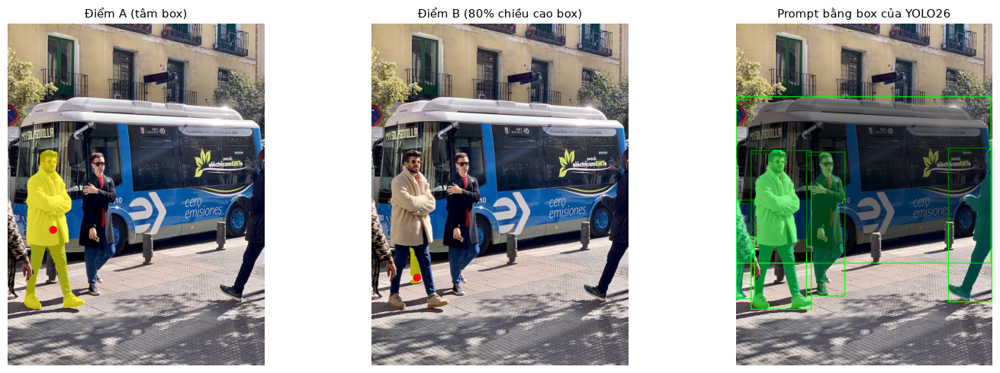

Điểm A: mask rộng  47441 pixel, IoU với mask-từ-box của người đó = 0.99
Điểm B: mask rộng   2714 pixel, IoU với mask-từ-box của người đó = 0.00


In [28]:
sam = SAM("sam2.1_t.pt")                                          # SAM 2.1 tiny
det_boxes, det_cls, det_conf = r_e2e.boxes.xyxy.cpu(), r_e2e.boxes.cls.cpu().int(), r_e2e.boxes.conf.cpu()

# (1) Prompt bằng MỘT ĐIỂM, lấy trong box 'person' lớn nhất: A = tâm box, B = cùng cột nhưng ở 80% chiều cao box
persons = det_boxes[det_cls == 0]
big = persons[((persons[:, 2] - persons[:, 0]) * (persons[:, 3] - persons[:, 1])).argmax()]
px = float((big[0] + big[2]) / 2)
pts = {"A": (px, float((big[1] + big[3]) / 2)), "B": (px, float(big[1] + 0.8 * (big[3] - big[1])))}
m_pts = {k: sam(IMG_BUS, points=[list(xy)], labels=[1], verbose=False)[0].masks.data.cpu().bool() for k, xy in pts.items()}

# (2) Prompt bằng BOX: toàn bộ box của detector
t0 = time.time()
masks_sam = sam(IMG_BUS, bboxes=det_boxes.tolist(), verbose=False)[0].masks.data.cpu().bool()       # (N,H,W) ở độ phân giải ảnh gốc
print(f"SAM 2.1-tiny: {len(masks_sam)} mask từ {len(det_boxes)} box prompt trong {time.time() - t0:.2f} giây")

pt_vis = {k: draw_keypoints(draw_segmentation_masks(img_bus, m_pts[k], alpha=0.6, colors="yellow"), torch.tensor([[list(xy)]]), colors="red", radius=12)
          for k, xy in pts.items()}
box_vis = draw_segmentation_masks(draw_det(img_bus, det_boxes, det_cls, det_conf, "lime", NAMES), masks_sam, alpha=0.5)
show(pt_vis["A"], pt_vis["B"], box_vis, titles=["Điểm A (tâm box)", "Điểm B (80% chiều cao box)", "Prompt bằng box của YOLO26"])
for k in pts:
    print(f"Điểm {k}: mask rộng {int(m_pts[k].sum()):6d} pixel, IoU với mask-từ-box của người đó = {float(mask_iou(m_pts[k], masks_sam).max()):.2f}")

5 0.012346 0.348148 0.016049 0.431481 0.023457 0.417593 0.030864 0.437037 0.013580 0.438889 0.030864 0.452778 0.020988 0.544444 0.060494 0.621296 0.080247 0.624 ...


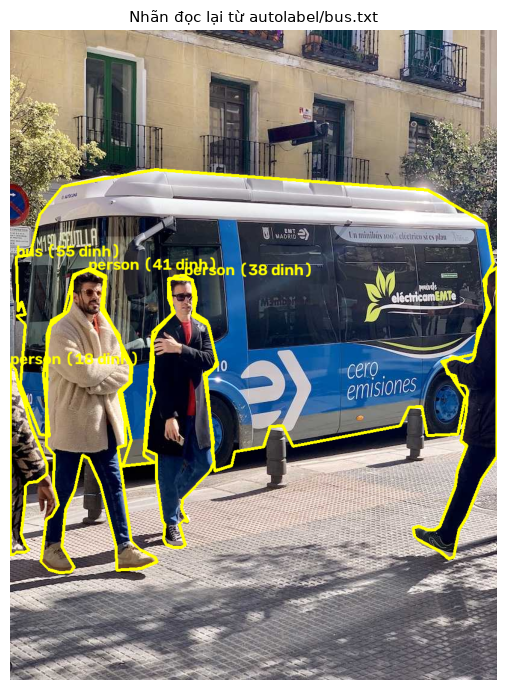

IoU giữa polygon đã lưu và mask SAM gốc: [0.97, 0.982, 0.967, 0.978, 0.983]
✅ autolabel/bus.txt hợp lệ: 5 object, toạ độ chuẩn hoá, polygon khớp mask.


In [29]:
# (3) Auto-label: mask của SAM → file nhãn YOLO-seg, dùng mask_to_yolo_seg của BẠN
lines = [mask_to_yolo_seg(m.numpy(), int(k)) for m, k in zip(masks_sam, det_cls)]
Path("autolabel").mkdir(exist_ok=True)
Path("autolabel/bus.txt").write_text("\n".join(l for l in lines if l) + "\n")
print(Path("autolabel/bus.txt").read_text()[:160], "...")

# (4) Luôn vẽ lại nhãn lên ảnh trước khi train: đọc file → polygon → mask, dùng polygon_to_mask của BẠN
canvas = cv2.cvtColor(cv2.imread(IMG_BUS), cv2.COLOR_BGR2RGB)
rebuilt = []
for line in Path("autolabel/bus.txt").read_text().splitlines():
    cls_id, coords = int(line.split()[0]), np.array(line.split()[1:], dtype=float).reshape(-1, 2)
    poly = coords * [W, H]                                        # bỏ chuẩn hoá: nhân lại với (W, H)
    rebuilt.append(polygon_to_mask(poly, H, W))
    cv2.polylines(canvas, [np.round(poly).astype(np.int32)], True, (255, 255, 0), 4)
    cv2.putText(canvas, f"{NAMES[cls_id]} ({len(poly)} dinh)", tuple(np.round(poly[0]).astype(int)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)
roundtrip = mask_iou(torch.from_numpy(np.stack(rebuilt)), masks_sam).diagonal()
show(canvas, titles=["Nhãn đọc lại từ autolabel/bus.txt"], size=7)
print("IoU giữa polygon đã lưu và mask SAM gốc:", [round(float(v), 3) for v in roundtrip])
check_autolabel(ref_masks=masks_sam)

❓ **Q6.** (a) Điểm A và điểm B cho ra mask của cái gì? Vì sao khi gán nhãn tự động, prompt bằng box an toàn hơn prompt bằng một điểm?
(b) Khi nào nên dùng SAM trực tiếp lúc triển khai, khi nào chỉ dùng SAM để **tạo nhãn** rồi train một YOLO26-seg nhỏ?

In [30]:
Q6 = """
(a) Điểm A sinh mask của toàn bộ người (47.441 pixel, IoU 0,99), còn điểm B chỉ bắt một mảnh nhỏ 2.714 pixel nên IoU xấp xỉ 0. Box prompt an toàn hơn vì cung cấp cả phạm vi và ngữ cảnh object, giảm tính mơ hồ của một điểm.
(b) Nên dùng SAM trực tiếp khi cần tương tác/prompt linh hoạt, class mới và chấp nhận latency cao. Khi bài toán cố định, cần real-time hoặc chạy edge, nên dùng SAM để tạo nhãn, sửa tay ca sai rồi train YOLO26-seg nhỏ.
"""

---
## Phần 3 — Keypoints và Pose (25')
🏭 **Mảnh ghép 3: phát hiện người ngã.** Box chỉ cho biết người ở đâu. Muốn biết *tư thế* thì cần cấu trúc bên trong object: K điểm có tên và có thứ tự.

### 3A. Hai cách ra keypoint: heatmap và hồi quy trực tiếp — 8'
- **Keypoint R-CNN** (top-down trong một model): detect người → RoIAlign → 17 heatmap cho mỗi người → lấy argmax.
- **YOLO26n-pose** (one-stage): một lần forward ra box + 17 keypoint cho mọi người, hồi quy toạ độ trực tiếp.

In [31]:
from torchvision.models.detection import keypointrcnn_resnet50_fpn

w_kp = KeypointRCNN_ResNet50_FPN_Weights.DEFAULT                  # COCO keypoint AP 65.0
kprcnn = keypointrcnn_resnet50_fpn(weights=w_kp).eval().to(DEVICE)
KPT_NAMES = w_kp.meta["keypoint_names"]                           # 17 keypoint theo thứ tự COCO
SKELETON = [(15, 13), (13, 11), (16, 14), (14, 12), (11, 12), (5, 11), (6, 12), (5, 6), (5, 7), (6, 8),
            (7, 9), (8, 10), (1, 2), (0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 6)]

with torch.inference_mode():
    ok = kprcnn([w_kp.transforms()(img_zidane).to(DEVICE)])[0]
ok = {k: v.cpu() for k, v in ok.items()}
keep = ok["scores"] > 0.7
kp_rcnn, kp_rcnn_score = ok["keypoints"][keep], ok["keypoints_scores"][keep]
print("Keypoint R-CNN:", tuple(kp_rcnn.shape), "= N × K × (x, y, v) · điểm từng keypoint:", tuple(kp_rcnn_score.shape), "(là LOGIT của heatmap, không phải xác suất)")

yolo_pose = YOLO("yolo26n-pose.pt")
rp = yolo_pose.predict(IMG_ZIDANE, conf=0.5, verbose=False)[0]
kp_yolo, kp_yolo_conf = rp.keypoints.xy.cpu(), rp.keypoints.conf.cpu()
print("YOLO26n-pose  :", tuple(kp_yolo.shape), "· conf từng keypoint:", tuple(kp_yolo_conf.shape), "(xác suất 0–1)")
show_table([{"#": i, "keypoint": n, "x": round(float(kp_yolo[0, i, 0])), "y": round(float(kp_yolo[0, i, 1])),
             "conf YOLO": float(kp_yolo_conf[0, i]), "logit R-CNN": float(kp_rcnn_score[0, i])} for i, n in enumerate(KPT_NAMES)],
           title=f"Người 0 trên zidane.jpg (ảnh cao {img_zidane.shape[1]} px — để ý y của các keypoint chân)")

Keypoint R-CNN: (2, 17, 3) = N × K × (x, y, v) · điểm từng keypoint: (2, 17) (là LOGIT của heatmap, không phải xác suất)


YOLO26n-pose  : (2, 17, 2) · conf từng keypoint: (2, 17) (xác suất 0–1)


**Người 0 trên zidane.jpg (ảnh cao 720 px — để ý y của các keypoint chân)**

| # | keypoint | x | y | conf YOLO | logit R-CNN |
|---|---|---|---|---|---|
| 0 | nose | 999 | 194 | 0.998 | 15.023 |
| 1 | left_eye | 1023 | 169 | 0.991 | 14.836 |
| 2 | right_eye | 965 | 164 | 0.999 | 15.896 |
| 3 | left_ear | 1044 | 187 | 0.182 | 11.755 |
| 4 | right_ear | 902 | 177 | 0.981 | 13.930 |
| 5 | left_shoulder | 1033 | 337 | 0.966 | 10.005 |
| 6 | right_shoulder | 835 | 329 | 0.996 | 6.701 |
| 7 | left_elbow | 1051 | 507 | 0.350 | 1.161 |
| 8 | right_elbow | 796 | 527 | 0.940 | 5.464 |
| 9 | left_wrist | 1071 | 483 | 0.310 | 4.289 |
| 10 | right_wrist | 976 | 467 | 0.931 | 10.376 |
| 11 | left_hip | 1047 | 706 | 0.271 | 2.500 |
| 12 | right_hip | 909 | 714 | 0.420 | 4.766 |
| 13 | left_knee | 1076 | 715 | 0.001 | -3.470 |
| 14 | right_knee | 931 | 718 | 0.002 | -1.534 |
| 15 | left_ankle | 1042 | 712 | 0.001 | -3.649 |
| 16 | right_ankle | 929 | 700 | 0.001 | -0.970 |

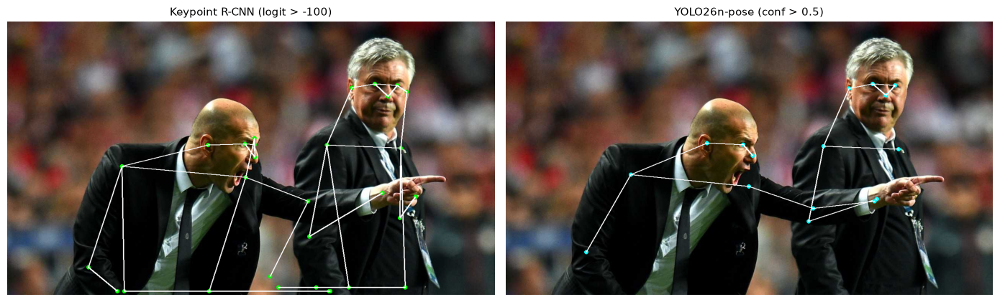

In [32]:
KP_THR = -100         # bỏ ngưỡng để quan sát cả keypoint có logit thấp / ngoài khung.

vis_rcnn = draw_keypoints(img_zidane, kp_rcnn[..., :2], connectivity=SKELETON, colors="lime", radius=5, width=3, visibility=kp_rcnn_score > KP_THR)
vis_yolo = draw_keypoints(img_zidane, kp_yolo, connectivity=SKELETON, colors="cyan", radius=5, width=3, visibility=kp_yolo_conf > 0.5)
show(vis_rcnn, vis_yolo, titles=[f"Keypoint R-CNN (logit > {KP_THR})", "YOLO26n-pose (conf > 0.5)"], size=7)

❓ **Q7.** Đổi `KP_THR = -100` rồi chạy lại ô trên. Đầu gối và mắt cá của hai người nằm **ngoài khung hình**, vậy Keypoint R-CNN vẽ chúng ở đâu? Điều đó nói gì về cách giải mã heatmap bằng argmax, và vì sao mỗi keypoint cần đi kèm một điểm tin cậy?

In [33]:
Q7 = """
Khi bỏ ngưỡng, Keypoint R-CNN vẫn vẽ đầu gối và mắt cá sát mép dưới/ở những vị trí không có bộ phận thật trong khung. Argmax luôn chọn một đỉnh heatmap dù heatmap chỉ là nhiễu, nên toạ độ tồn tại không có nghĩa là keypoint đáng tin.
Vì vậy mỗi keypoint cần score riêng để loại các điểm bị che, nằm ngoài ảnh hoặc không có bằng chứng; trong bảng, các logit chân có thể xuống tới -3,65.
"""

### 3B. 🧩 OKS — "IoU của keypoint" — 10'
$$\mathrm{OKS}=\frac{\sum_i \exp\!\left(-\dfrac{d_i^2}{2\,s^2\,k_i^2}\right)\,\delta(v_i>0)}{\sum_i \delta(v_i>0)},\qquad k_i = 2\sigma_i$$
- $d_i$: khoảng cách giữa keypoint dự đoán và GT · $s^2$: **diện tích** object;
- $\sigma_i$: độ lệch giữa những người gán nhãn cho keypoint $i$ (mắt 0.025, hông 0.107);
- chỉ tính các keypoint có nhãn ($v_i > 0$).

🔮 **Dự đoán** (câu checkpoint trên slide). Cùng một người, dự đoán lệch 8 pixel ở **mắt** và ở **hông**. Keypoint nào bị phạt nặng hơn?

In [34]:
COCO_SIGMAS = np.array([.26, .25, .25, .35, .35, .79, .79, .72, .72, .62, .62, 1.07, 1.07, .87, .87, .89, .89]) / 10


def oks(kpt_gt: np.ndarray, kpt_pred: np.ndarray, area: float, sigmas: np.ndarray = COCO_SIGMAS, vis: np.ndarray = None) -> float:
    """kpt_gt, kpt_pred: (K,2) pixel · area: diện tích object (chính là s²) · sigmas: (K,) · vis: (K,) bool, keypoint GT có nhãn."""
    kpt_gt, kpt_pred = np.asarray(kpt_gt, dtype=float), np.asarray(kpt_pred, dtype=float)
    if vis is None:
        vis = np.ones(len(kpt_gt), dtype=bool)
    # Bước 1 — bình phương khoảng cách của từng keypoint: d² = Δx² + Δy²
    d2 = ((kpt_gt - kpt_pred) ** 2).sum(axis=1)                   # (K,)  🧩
    # Bước 2 (viết sẵn) — hằng số của từng keypoint
    k = 2 * np.asarray(sigmas)
    # Bước 3 — độ giống của từng keypoint: exp(−d² / (2 · s² · k²)), với s² = area
    sim = np.exp(-d2 / (2 * area * k ** 2))                       # (K,)  🧩
    # Bước 4 — trung bình trên các keypoint CÓ NHÃN
    return float(sim[vis].mean())                                 # 🧩


check_oks()

✅ oks đạt (3 phép thử)


<details><summary>💡 Gợi ý — <code>oks</code></summary>

Bước 1: `((kpt_gt - kpt_pred) ** 2).sum(axis=1)`. Bước 3: `np.exp(-d2 / (2 * area * k ** 2))` — chú ý `area` đã là $s^2$, đừng bình phương thêm.
Bước 4: `float(sim[vis].mean())`.
</details>

In [35]:
gate("3B")        # 🚦 hết 10 phút mà chưa xong? → gate("3B", lifeline=True)

✅ Mục 3B xong: oks. Đi tiếp!


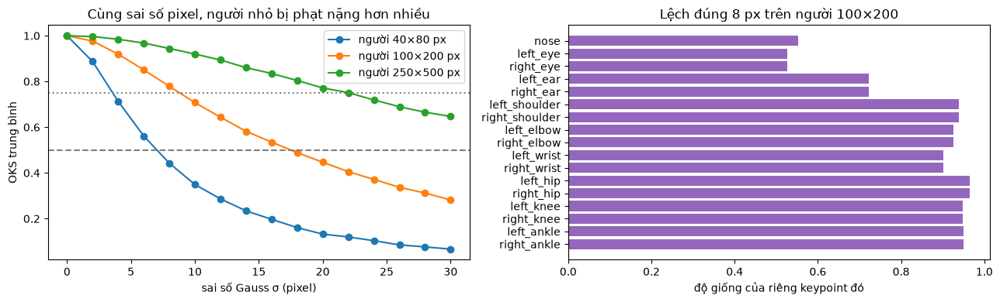

Lệch 8 px: mắt còn 0.53, hông còn 0.97 → mắt bị phạt nặng hơn.


In [36]:
# Thí nghiệm: cùng sai số pixel, OKS thay đổi thế nào theo KÍCH THƯỚC người và theo TỪNG keypoint?
rng = np.random.default_rng(0)
gt17 = rng.uniform(0, 100, (17, 2))
noise_px = np.arange(0, 31, 2)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for label, area_ in [("40×80 px", 40 * 80), ("100×200 px", 100 * 200), ("250×500 px", 250 * 500)]:
    curve = [np.mean([oks(gt17, gt17 + rng.normal(0, n, gt17.shape), area_) for _ in range(200)]) for n in noise_px]
    ax[0].plot(noise_px, curve, marker="o", label=f"người {label}")
ax[0].axhline(0.5, ls="--", c="gray"); ax[0].axhline(0.75, ls=":", c="gray")
ax[0].set(xlabel="sai số Gauss σ (pixel)", ylabel="OKS trung bình", title="Cùng sai số pixel, người nhỏ bị phạt nặng hơn nhiều"); ax[0].legend()

d_px, area_ = 8.0, 100 * 200
per_kpt = np.exp(-d_px ** 2 / (2 * area_ * (2 * COCO_SIGMAS) ** 2))
ax[1].barh(KPT_NAMES, per_kpt, color="tab:purple"); ax[1].invert_yaxis()
ax[1].set(xlabel="độ giống của riêng keypoint đó", title=f"Lệch đúng {d_px:.0f} px trên người 100×200")
plt.tight_layout(); plt.show()
print(f"Lệch 8 px: mắt còn {per_kpt[1]:.2f}, hông còn {per_kpt[11]:.2f} → mắt bị phạt nặng hơn.")

❓ **Q8.** Từ đồ thị bên trái: sai số khoảng bao nhiêu pixel thì OKS của người 40×80 rơi xuống dưới 0.5? Người 250×500 thì sao?
Vì sao $\sigma$ của mắt nhỏ hơn hông nhiều lần? Điều này có ý nghĩa gì với camera cổng gắn trên cao, nơi mỗi người chỉ cao khoảng 80 pixel?

In [37]:
Q8 = """
Người 40×80 rơi xuống dưới OKS 0,5 ở sai số khoảng 8 pixel; người 250×500 vẫn còn khoảng 0,65 ở 30 pixel, nên phải lệch trên 30 pixel mới xuống dưới 0,5. Sigma của mắt nhỏ vì người gán nhãn thống nhất vị trí mắt chính xác hơn, còn hông rộng và mơ hồ hơn; vì vậy lệch 8 pixel làm mắt còn 0,53 nhưng hông còn 0,97.
Với camera trên cao và người chỉ cao khoảng 80 pixel, vài pixel sai số đã là tỉ lệ lớn; cần ảnh đủ phân giải, ROI/crop phù hợp và ngưỡng tin cậy theo keypoint.
"""

### 3C. 🧩 Từ keypoint đến luật nghiệp vụ: góc khớp và "ngã" — 7'
Góc tại đỉnh $b$ tạo bởi ba điểm $a$–$b$–$c$:
$$\theta=\arccos\frac{(a-b)\cdot(c-b)}{\lVert a-b\rVert\,\lVert c-b\rVert}$$

In [38]:
def joint_angle(a, b, c) -> float:
    """Góc (độ) tại đỉnh b tạo bởi ba điểm a–b–c. Mỗi điểm là (x, y)."""
    a, b, c = (np.asarray(p, dtype=float) for p in (a, b, c))
    # Bước 1 — hai vector cùng xuất phát từ b
    v1 = a - b
    v2 = c - b                                                    # 🧩
    # Bước 2 — cos θ = (v1 · v2) / (|v1| · |v2|). Gợi ý: np.dot, np.linalg.norm
    cos = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))  # 🧩
    # Bước 3 (viết sẵn) — chặn cos trong [−1, 1] để tránh sai số số học, rồi đổi sang độ
    return float(np.degrees(np.arccos(np.clip(cos, -1.0, 1.0))))


check_joint_angle()

✅ joint_angle đạt (2 phép thử)


<details><summary>💡 Gợi ý — <code>joint_angle</code></summary>

`v2 = c - b` và `cos = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))`.
</details>

In [39]:
gate("3C")        # 🚦 hết giờ mà chưa xong? → gate("3C", lifeline=True)

✅ Mục 3C xong: joint_angle. Đi tiếp!


zidane.jpg — người 0: tay trái: (không đủ tin cậy) | tay phải: 61°
zidane.jpg — người 1: tay trái: 154° | tay phải: (không đủ tin cậy)

Ảnh gốc: tìm thấy 5 người
   người 0: thân nghiêng   1° → đứng
   người 1: không đủ tin cậy (vai hoặc hông bị che / ngoài khung) → không kết luận
   người 2: thân nghiêng   1° → đứng
   người 3: không đủ tin cậy (vai hoặc hông bị che / ngoài khung) → không kết luận
   người 4: không đủ tin cậy (vai hoặc hông bị che / ngoài khung) → không kết luận

Xoay 90° — giả lập người nằm: tìm thấy 3 người
   người 0: thân nghiêng  90° → 🚨 NGÃ?
   người 1: thân nghiêng  94° → 🚨 NGÃ?
   người 2: thân nghiêng  83° → 🚨 NGÃ?


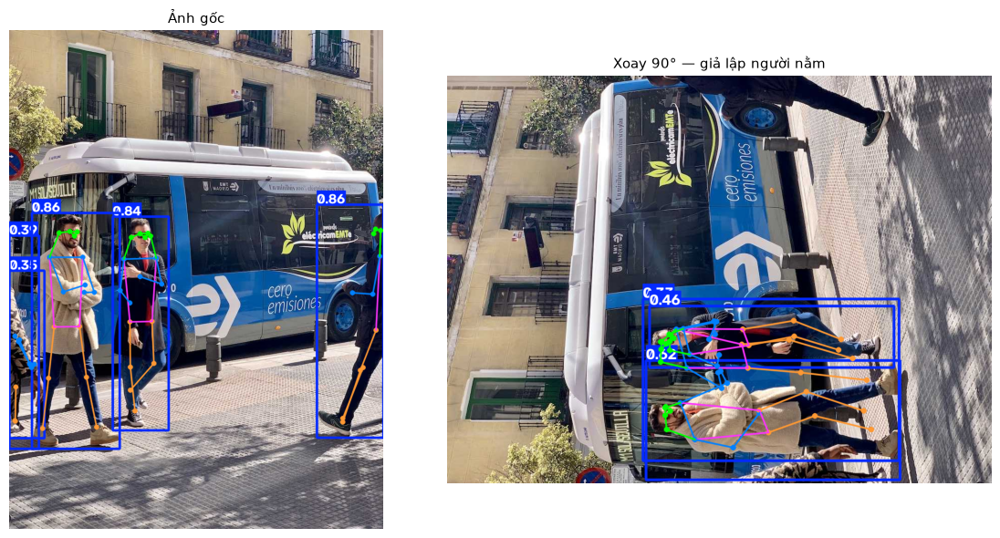

In [40]:
# (1) Góc khuỷu tay trên zidane.jpg — chỉ tin khi cả 3 keypoint đều đủ tin cậy
ARMS = {"tay trái": (5, 7, 9), "tay phải": (6, 8, 10)}            # vai – khuỷu – cổ tay (chỉ số COCO)
for i, (kp, cf) in enumerate(zip(kp_yolo.numpy(), kp_yolo_conf.numpy())):
    parts = [f"{arm}: {joint_angle(kp[s_], kp[e_], kp[w_]):.0f}°" if min(cf[s_], cf[e_], cf[w_]) > 0.5 else f"{arm}: (không đủ tin cậy)"
             for arm, (s_, e_, w_) in ARMS.items()]
    print(f"zidane.jpg — người {i}: " + " | ".join(parts))


# (2) Luật "ngã": góc nghiêng của thân so với phương thẳng đứng
def torso_tilt(kp):
    """0° = đứng thẳng, 90° = nằm ngang. Thân = đoạn nối trung điểm hai vai với trung điểm hai hông."""
    shoulder, hip = (kp[5] + kp[6]) / 2, (kp[11] + kp[12]) / 2
    return joint_angle(shoulder, hip, hip + np.array([0.0, -1.0]))    # điểm thứ ba nằm ngay phía TRÊN hông (trục y của ảnh hướng xuống)


FALL_DEG, KPT_CONF = 60, 0.5
img_bgr = cv2.imread(IMG_BUS)
scenes = {"Ảnh gốc": img_bgr, "Xoay 90° — giả lập người nằm": cv2.rotate(img_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)}
plots = []
for title, im in scenes.items():
    r = yolo_pose.predict(im, conf=0.25, verbose=False)[0]
    plots.append(bgr_to_u8(r.plot(labels=False)))
    print(f"\n{title}: tìm thấy {len(r.boxes)} người")
    for i, (kp, cf) in enumerate(zip(r.keypoints.xy.cpu().numpy(), r.keypoints.conf.cpu().numpy())):
        if cf[[5, 6, 11, 12]].min() < KPT_CONF:
            print(f"   người {i}: không đủ tin cậy (vai hoặc hông bị che / ngoài khung) → không kết luận")
        else:
            tilt = torso_tilt(kp)
            print(f"   người {i}: thân nghiêng {tilt:3.0f}° → {'🚨 NGÃ?' if tilt > FALL_DEG else 'đứng'}")
show(*plots, titles=list(scenes), size=6)

❓ **Q9.** (a) Luật "thân nghiêng > 60°" sẽ **báo nhầm** trong tình huống nào và **bỏ sót** trong tình huống nào? Nêu mỗi loại ít nhất một ca.
(b) Ảnh xoay vẫn có đủ số người như ảnh gốc, nhưng model tìm được ít người hơn. Vì sao?
(c) Một hệ thống cảnh báo ngã thật sự cần thêm những thành phần gì ngoài một luật trên một khung hình?

In [41]:
Q9 = """
(a) Luật >60° có thể báo nhầm người đang cúi nhặt đồ, bò/làm việc sát sàn hoặc khi camera bị nghiêng; nó có thể bỏ sót người ngã theo hướng chiếu vẫn trông thẳng, bị che khuất hoặc vai/hông có score thấp.
(b) Ảnh xoay 90° là distribution shift so với dữ liệu người thường đứng; detector/pose model không bất biến quay nên chỉ tìm thấy 3 người thay vì 5.
(c) Hệ thống thật cần tracking nhiều khung hình, tốc độ/thay đổi tư thế, hiệu chỉnh camera và mặt sàn, xử lý che khuất, ngưỡng duy trì cảnh báo và bước xác nhận để giảm báo giả.
"""

---
## Phần 4 — Fine-tune YOLO26n-pose trên dữ liệu custom (20')
🏭 **Mảnh ghép 4: dạy model một đối tượng mới.** Nhà máy sẽ không có sẵn model cho đúng thứ bạn cần. Ta tập dượt với **tiger-pose**:
210 ảnh train, 53 ảnh val, 1 class, **12 keypoint**. Bài học chính không nằm ở lệnh `train`, mà ở câu hỏi: *tập val có đủ để lộ ra lỗi không?*

kpt_shape: [12, 2] | flip_idx trong YAML gốc: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Tên 12 keypoint: {0: 'nose', 1: 'head', 2: 'withers', 3: 'tail_base', 4: 'right_hind_hock', 5: 'right_hind_paw', 6: 'left_hind_paw', 7: 'left_hind_hock', 8: 'right_front_wrist', 9: 'right_front_paw', 10: 'left_front_wrist', 11: 'left_front_paw'}


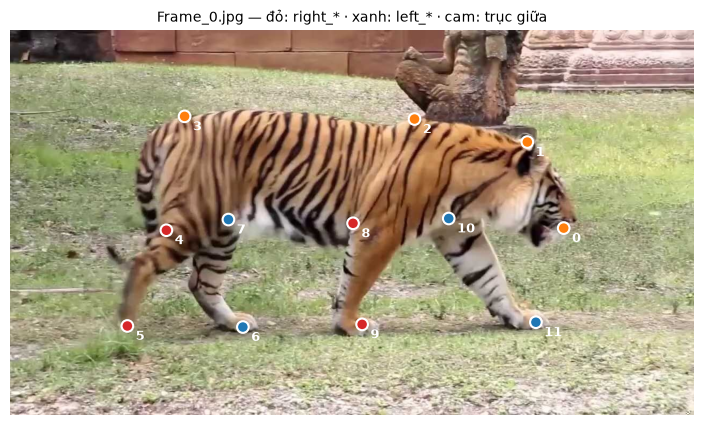

In [42]:
# Giải phóng bộ nhớ của các model Phần 1–3 trước khi train
for _name in ["frcnn", "mrcnn", "kprcnn", "sam", "yolo_sem", "yolo_seg"]:
    G.pop(_name, None)
gc.collect()
if GPU:
    torch.cuda.empty_cache()

TIGER_KPTS = TIGER["kpt_names"][0]
TIGER_ROOT = Path(TIGER["path"])
print("kpt_shape:", TIGER["kpt_shape"], "| flip_idx trong YAML gốc:", TIGER["flip_idx"])
print("Tên 12 keypoint:", {i: n for i, n in enumerate(TIGER_KPTS)})


def tiger_label(img_path):
    """Đọc nhãn YOLO-pose của một ảnh → (box xyxy theo pixel, keypoint (12,2) theo pixel). Mỗi dòng: class cx cy w h x1 y1 … x12 y12."""
    img_path = Path(img_path)
    h, w = cv2.imread(str(img_path)).shape[:2]
    row = np.loadtxt(img_path.parents[2] / "labels" / img_path.parent.name / (img_path.stem + ".txt"), ndmin=2)[0]
    cx, cy, bw, bh = row[1:5] * [w, h, w, h]
    return np.array([cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2]), row[5:].reshape(-1, 2) * [w, h]


sample = sorted((TIGER_ROOT / "images" / "train").glob("*.jpg"))[0]
sample_rgb = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
_, sample_kp = tiger_label(sample)
fig, ax = plt.subplots(figsize=(9, 5))
plot_kpts(ax, sample_rgb, sample_kp, TIGER_KPTS, title=f"{sample.name} — đỏ: right_* · xanh: left_* · cam: trục giữa")
for i, (x, y) in enumerate(sample_kp):
    ax.annotate(str(i), (x, y), xytext=(6, -10), textcoords="offset points", color="white", fontsize=9, weight="bold")
plt.show()

### 4A. 🧩 `flip_idx` và quy ước trái/phải — 6'
Augmentation **lật ngang** (`fliplr=0.5`) tạo ra ảnh gương. `flip_idx[i] = j` nghĩa là: sau khi lật, điểm ở vị trí `i` mang nhãn của keypoint `j`.
- Nếu nhãn là **giải phẫu** (chân phải *thật* của con hổ) thì trong ảnh gương, chân phải trông như chân trái ⇒ phải **hoán đổi** từng cặp `left_*` ↔ `right_*`.
- YAML gốc dùng `flip_idx` **đồng nhất** `[0, 1, …, 11]`, tức là không hoán đổi gì.

Trước hết, xem hổ trong dataset quay về hướng nào (mũi ở bên phải hay bên trái gốc đuôi).

In [43]:
def facing(split):
    right = left = 0
    for f in (TIGER_ROOT / "labels" / split).glob("*.txt"):
        for row in np.loadtxt(f, ndmin=2):
            k = row[5:].reshape(-1, 2)
            right += k[0, 0] > k[3, 0]          # nose.x > tail_base.x → quay phải
            left += k[0, 0] <= k[3, 0]
    return int(right), int(left)


FACING = {split: facing(split) for split in ("train", "val")}
for split, (r_, l_) in FACING.items():
    print(f"{split:5s}: quay phải = {r_:3d} | quay trái = {l_:3d}")

train: quay phải = 210 | quay trái =   0
val  : quay phải =  53 | quay trái =   0


❓ **Q10.** Mọi con hổ ở cả train **lẫn** val đều quay sang phải. Vậy nếu giữ `flip_idx` đồng nhất, mAP trên tập val này có giảm không?
Trong tình huống triển khai nào thì nó trở thành bug thật sự? (Trả lời trong lúc chờ train ở 4B cũng được.)

In [44]:
Q10 = """
mAP trên val gốc có thể không giảm rõ vì cả 210 ảnh train và 53 ảnh val đều là hổ quay phải; tập val không kiểm tra miền quay trái nên metric có thể che bug, dù nhãn augmentation sai vẫn có thể gây nhiễu. Bug trở thành lỗi thật khi triển khai gặp hổ quay trái, camera ở phía đối diện hoặc ảnh bị lật gương, lúc đó keypoint left/right sẽ bị đảo.
"""

**🧩 TODO.** Viết `FLIP_IDX` theo quy ước **giải phẫu**: hoán đổi từng cặp `left_X` ↔ `right_X`, các điểm trên trục giữa (nose, head, withers, tail_base) giữ nguyên.
Nhìn bảng tên 12 keypoint in ở trên để tìm cặp. Ví dụ: `right_hind_hock` là số 4, `left_hind_hock` là số 7, nên `FLIP_IDX[4] = 7` và `FLIP_IDX[7] = 4`.

In [45]:
FLIP_IDX = [0, 1, 2, 3, 7, 6, 5, 4, 10, 11, 8, 9]      # 🧩 hoán đổi các cặp keypoint right_* ↔ left_*

check_flip_idx()

✅ FLIP_IDX đạt (4 phép thử)


✅ Mục 4A xong: FLIP_IDX. Đi tiếp!


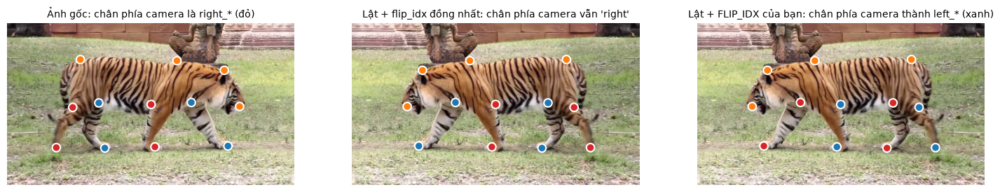

In [46]:
gate("4A")        # 🚦 chưa xong? → gate("4A", lifeline=True)

# Ghi YAML mới và xem tận mắt hai quy ước trên một ảnh lật gương
cfg = dict(path=str(TIGER_ROOT), train="images/train", val="images/val", kpt_shape=[12, 2], flip_idx=list(FLIP_IDX),
           names={0: "tiger"}, kpt_names={0: list(TIGER_KPTS)})
yaml.safe_dump(cfg, open("tiger-pose-anat.yaml", "w"), sort_keys=False)

flipped = sample_rgb[:, ::-1]
kp_flip = sample_kp.copy(); kp_flip[:, 0] = sample_rgb.shape[1] - kp_flip[:, 0]      # lật toạ độ x
names_anat = [TIGER_KPTS[j] for j in FLIP_IDX]                                        # tên mà mỗi điểm mang sau khi lật (giải phẫu)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
plot_kpts(ax[0], sample_rgb, sample_kp, TIGER_KPTS, "Ảnh gốc: chân phía camera là right_* (đỏ)")
plot_kpts(ax[1], flipped, kp_flip, TIGER_KPTS, "Lật + flip_idx đồng nhất: chân phía camera vẫn 'right'")
plot_kpts(ax[2], flipped, kp_flip, names_anat, "Lật + FLIP_IDX của bạn: chân phía camera thành left_* (xanh)")
plt.show()

### 4B. Train, đo, và nhìn vào lỗi — 12'
Transfer learning từ `yolo26n-pose.pt` (17 keypoint người): backbone và neck được giữ, phần keypoint của head được khởi tạo lại cho 12 keypoint.
Với GPU, ô train chạy 40 epoch và mất vài phút. **Trong lúc chờ, hãy trả lời Q10 ở trên.**

In [47]:
EPOCHS, IMGSZ = (40, 640) if GPU else (3, 320)                    # không có GPU thì chỉ chạy thử cho thông pipeline

pose_model = YOLO("yolo26n-pose.pt")
t0 = time.time()
pose_model.train(data="tiger-pose-anat.yaml", epochs=EPOCHS, imgsz=IMGSZ, batch=16, device=0 if GPU else "cpu", workers=2, seed=0,
                 project="runs_lab", name="tiger_anat", exist_ok=True, verbose=False)
TRAIN_MIN = (time.time() - t0) / 60
SAVE_DIR = Path(pose_model.trainer.save_dir)
print(f"⏱  Train xong trong {TRAIN_MIN:.1f} phút — kết quả lưu ở {SAVE_DIR}")

New https://pypi.org/project/ultralytics/8.4.173 available  Update with 'pip install -U ultralytics'


Ultralytics 8.4.171  Python-3.13.15 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=tiger-pose-anat.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tiger_anat, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, p

Overriding model.yaml kpt_shape=[17, 3] with kpt_shape=[12, 2]



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8it/s 1.1s

                   all         53         53      0.999          1      0.995      0.929      0.999          1      0.995      0.402


Speed: 1.0ms preprocess, 3.9ms inference, 0.0ms loss, 3.6ms postprocess per image


Results saved to C:\Users\PC\Track04-Day18-2D-perception-detection-segmentation-keypoints\runs\pose\runs_lab\tiger_anat


⏱  Train xong trong 4.0 phút — kết quả lưu ở C:\Users\PC\Track04-Day18-2D-perception-detection-segmentation-keypoints\runs\pose\runs_lab\tiger_anat


Ultralytics 8.4.171  Python-3.13.15 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)


YOLO26n-pose summary (fused): 129 layers, 2,634,591 parameters, 0 gradients, 6.3 GFLOPs


val: Fast image access  (ping: 0.00.0 ms, read: 1856.1255.5 MB/s, size: 212.9 KB)


val: Scanning C:\Users\PC\Track04-Day18-2D-perception-detection-segmentation-keypoints\datasets\tiger-pose\labels\val.cache... 53 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 53/53 20.2Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 25% ━━━───────── 1/4 9.0s/it 2.7s<26.9s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 75% ━━━━━━━━━─── 3/4 2.3it/s 3.2s<0.4s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2it/s 3.3s

                   all         53         53      0.999          1      0.995      0.929      0.999          1      0.995      0.401


Speed: 0.8ms preprocess, 6.8ms inference, 0.0ms loss, 4.4ms postprocess per image


**Kết quả trên tiger-pose val (53 ảnh)**

| flip_idx | epochs | imgsz | Box mAP50-95 | Pose mAP50 | Pose mAP50-95 | train (phút) |
|---|---|---|---|---|---|---|
| giải phẫu | 40 | 640 | 0.929 | 0.995 | 0.401 | 4.000 |

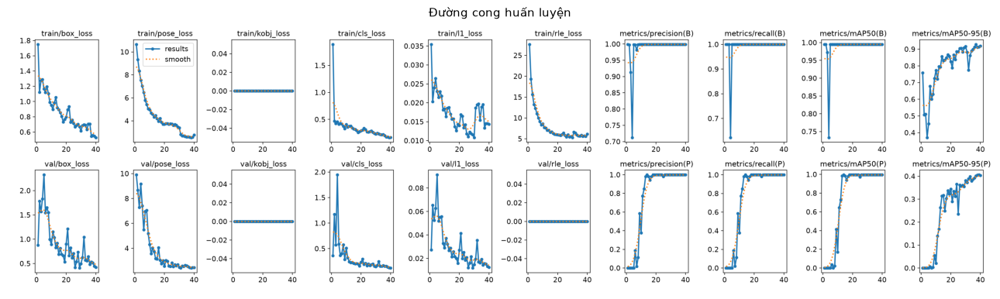

In [48]:
metrics = pose_model.val(data="tiger-pose-anat.yaml", imgsz=IMGSZ, batch=16, verbose=False, plots=False)
RESULT_4B = {"flip_idx": "giải phẫu", "epochs": EPOCHS, "imgsz": IMGSZ, "Box mAP50-95": float(metrics.box.map),
             "Pose mAP50": float(metrics.pose.map50), "Pose mAP50-95": float(metrics.pose.map), "train (phút)": round(TRAIN_MIN, 1)}
show_table([RESULT_4B], title="Kết quả trên tiger-pose val (53 ảnh)")
if (SAVE_DIR / "results.png").exists():
    show(cv2.cvtColor(cv2.imread(str(SAVE_DIR / "results.png")), cv2.COLOR_BGR2RGB), titles=["Đường cong huấn luyện"], size=13)

Một con số mAP không nói model sai **ở đâu**. Bước tiếp theo của vòng lặp phân tích lỗi: chấm từng ảnh val bằng chính hàm `oks` của bạn, rồi **nhìn tận mắt** những ảnh tệ nhất.

OKS trung bình: 0.715 | không phát hiện được hổ: 0/53 ảnh | nghi đảo trái ↔ phải (đổi nhãn trái/phải thì OKS lại cao hơn): 16/53 ảnh


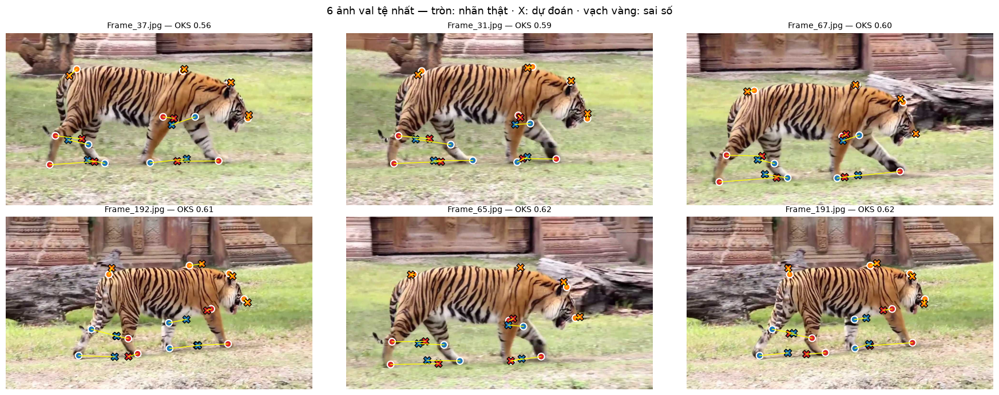

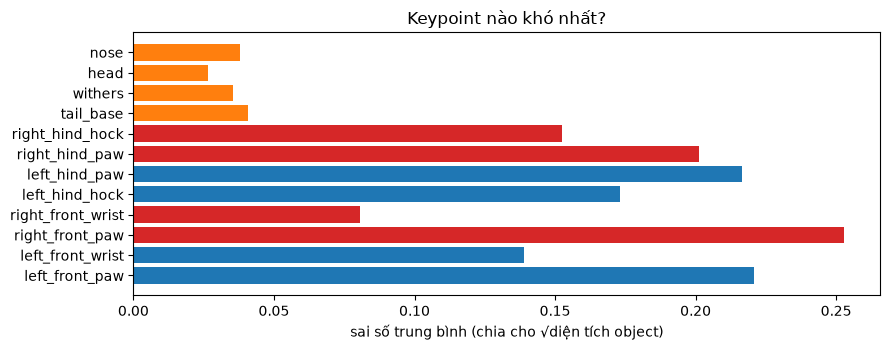

In [49]:
SIGMA_TIGER = np.full(12, 1 / 12)                                 # σ mà Ultralytics dùng cho dataset không phải 17 keypoint người: đều nhau, = 1/K
val_imgs = sorted((TIGER_ROOT / "images" / "val").glob("*.jpg"))
records = []
for p, r in zip(val_imgs, pose_model.predict([str(p) for p in val_imgs], imgsz=IMGSZ, conf=0.25, verbose=False, stream=True)):
    gt_box, gt_kp = tiger_label(p)
    area = float((gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])) * 0.53      # 0.53: hệ số Ultralytics dùng để đổi diện tích box → diện tích object
    rec = {"path": p, "gt": gt_kp, "pred": None, "oks": 0.0, "oks_swapped": 0.0, "err": np.full(12, np.nan)}
    if len(r.boxes):
        pk = r.keypoints.xy[int(r.boxes.conf.argmax())].cpu().numpy()
        rec.update(pred=pk, oks=oks(gt_kp, pk, area, sigmas=SIGMA_TIGER), oks_swapped=oks(gt_kp, pk[FLIP_IDX], area, sigmas=SIGMA_TIGER),
                   err=np.linalg.norm(pk - gt_kp, axis=1) / math.sqrt(area))
    records.append(rec)

missed = sum(r["pred"] is None for r in records)
swapped = sum(r["oks_swapped"] > r["oks"] + 0.02 for r in records)
print(f"OKS trung bình: {np.mean([r['oks'] for r in records]):.3f} | không phát hiện được hổ: {missed}/{len(records)} ảnh | "
      f"nghi đảo trái ↔ phải (đổi nhãn trái/phải thì OKS lại cao hơn): {swapped}/{len(records)} ảnh")

worst = sorted(records, key=lambda r: r["oks"])[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
for ax, rec in zip(axes.flat, worst):
    plot_kpts(ax, cv2.cvtColor(cv2.imread(str(rec["path"])), cv2.COLOR_BGR2RGB), rec["gt"], TIGER_KPTS, f"{rec['path'].name} — OKS {rec['oks']:.2f}")
    if rec["pred"] is not None:
        ax.scatter(rec["pred"][:, 0], rec["pred"][:, 1], s=90, c=[SIDE_COLORS[side_of(n)] for n in TIGER_KPTS], marker="X", edgecolors="black", linewidths=1)
        for g_, p_ in zip(rec["gt"], rec["pred"]):
            ax.plot([g_[0], p_[0]], [g_[1], p_[1]], color="yellow", lw=1)
fig.suptitle("6 ảnh val tệ nhất — tròn: nhãn thật · X: dự đoán · vạch vàng: sai số", fontsize=13); plt.tight_layout(); plt.show()

mean_err = np.nanmean(np.stack([r["err"] for r in records]), axis=0) if missed < len(records) else np.zeros(12)
plt.figure(figsize=(9, 3.6))
plt.barh(TIGER_KPTS, mean_err, color=[SIDE_COLORS[side_of(n)] for n in TIGER_KPTS]); plt.gca().invert_yaxis()
plt.xlabel("sai số trung bình (chia cho √diện tích object)"); plt.title("Keypoint nào khó nhất?"); plt.tight_layout(); plt.show()

❓ **Q11. Phân tích lỗi.** Nhìn 6 ảnh tệ nhất và biểu đồ sai số theo keypoint. Chỉ ra **hai kiểu lỗi** bạn thấy (ví dụ: đảo chân trái/phải, chân sau che nhau, hổ bị cắt ở mép ảnh, keypoint mơ hồ…) và đề xuất cách khắc phục cho từng kiểu (dữ liệu, augmentation, kiến trúc, hay ngưỡng).

In [50]:
Q11 = """
Kiểu lỗi 1 là nhầm trái/phải: 16/53 ảnh có OKS tăng nếu hoán đổi nhãn, và trong Frame_37/Frame_31 các dự đoán đỏ-xanh ở các chân bị bắt chéo. Cách khắc phục là bổ sung hổ quay cả hai hướng, giữ FLIP_IDX giải phẫu và tạo val cân bằng hướng quay để metric lộ lỗi.
Kiểu lỗi 2 là sai số lớn ở bàn chân/khớp xa khi chân giao nhau, bị che hoặc nhoè do chuyển động; biểu đồ cho thấy right_front_paw khó nhất (~0,25), sau đó left_front_paw và left_hind_paw (~0,22), và các vạch vàng dài xuất hiện rõ trong Frame_192/Frame_191. Nên thêm ảnh cận cảnh và ca che khuất, gán visibility cho keypoint mơ hồ, dùng crop/độ phân giải cao hơn và augmentation blur có kiểm soát.
"""

❓ **Q12.** Dataset này có 12 keypoint chứ không phải 17 keypoint người. Ô trên dùng `SIGMA_TIGER = 1/12` cho mọi keypoint, giống cách Ultralytics chấm mAP.
Điều đó có hợp lý không khi so mũi hổ với gốc đuôi? Bạn sẽ ước lượng $\sigma$ cho một dataset custom bằng cách nào?

In [51]:
Q12 = """
Dùng cùng sigma=1/12 cho mọi keypoint không hoàn toàn hợp lý: mũi có mốc nhỏ và rõ, trong khi gốc đuôi hay khớp chân có vùng hợp lệ rộng, dễ bị che và có độ mơ hồ khác nhau. Sigma nên được ước lượng bằng cách cho nhiều annotator gán lặp một tập ảnh, tính độ lệch chuẩn khoảng cách cho từng keypoint sau khi chuẩn hoá theo căn bậc hai diện tích object.
Sau đó dùng thống kê robust/loại ca gán sai và kiểm chứng sigma trên tập val độc lập; keypoint có độ bất đồng annotator cao sẽ nhận sigma lớn hơn.
"""

### 4C. ⭐ Tập val lật gương: metric nào lộ ra lỗi `flip_idx`? — về nhà hoặc nếu còn thời gian
Tạo một tập **val lật gương** (ảnh lật ngang, nhãn chuyển theo quy ước giải phẫu) để giả lập hổ quay trái lúc triển khai, rồi đo lại.
Đặt `TRAIN_IDENTITY = True` để train thêm một model với `flip_idx` đồng nhất (tốn thêm một lần train như ở 4B) và so sánh hai model trên cả hai tập val.

🔮 **Dự đoán** trước khi chạy: model nào tụt mAP trên val lật gương, và tụt nhiều hay ít?

In [52]:
RUN_4C = False                # ⭐ đổi thành True để chạy
TRAIN_IDENTITY = False        # ⭐ train thêm model flip_idx đồng nhất để so sánh
RESULT_4C = None


def make_mirrored_val(src_root, dst_root, flip_idx):
    """Val lật gương: ảnh lật ngang, x → 1 − x, keypoint đổi chỗ theo flip_idx (quy ước giải phẫu)."""
    src_root, dst_root = Path(src_root), Path(dst_root)
    for sub in ("images/val", "labels/val"):
        (dst_root / sub).mkdir(parents=True, exist_ok=True)
    for img_p in (src_root / "images/val").glob("*.jpg"):
        cv2.imwrite(str(dst_root / "images/val" / img_p.name), cv2.flip(cv2.imread(str(img_p)), 1))
        rows = []
        for row in np.loadtxt(src_root / "labels/val" / (img_p.stem + ".txt"), ndmin=2):
            box = row[1:5].copy(); box[0] = 1 - box[0]
            k = row[5:].reshape(-1, 2).copy(); k[:, 0] = 1 - k[:, 0]; k = k[flip_idx]
            rows.append(" ".join(f"{v:.6f}" for v in [row[0], *box, *k.flatten()]))
        (dst_root / "labels/val" / (img_p.stem + ".txt")).write_text("\n".join(rows) + "\n")
    return dst_root.resolve()


if RUN_4C:
    mirror_root = make_mirrored_val(TIGER_ROOT, "tiger-pose-mirror", FLIP_IDX)
    yaml.safe_dump(dict(cfg, path=str(mirror_root), train=str(TIGER_ROOT / "images/train")), open("tiger-pose-mirror.yaml", "w"), sort_keys=False)
    models = {"flip_idx giải phẫu": pose_model}
    if TRAIN_IDENTITY:
        m_id = YOLO("yolo26n-pose.pt")
        m_id.train(data="tiger-pose.yaml", epochs=EPOCHS, imgsz=IMGSZ, batch=16, device=0 if GPU else "cpu", workers=2, seed=0,
                   project="runs_lab", name="tiger_identity", exist_ok=True, verbose=False)
        models["flip_idx đồng nhất"] = m_id
    RESULT_4C = []
    for name, m in models.items():
        a = m.val(data="tiger-pose-anat.yaml", imgsz=IMGSZ, batch=16, verbose=False, plots=False).pose.map
        b_ = m.val(data="tiger-pose-mirror.yaml", imgsz=IMGSZ, batch=16, verbose=False, plots=False).pose.map
        RESULT_4C.append({"Model": name, "Pose mAP50-95 — val gốc": float(a), "Pose mAP50-95 — val lật gương": float(b_)})
    show_table(RESULT_4C, title="Val gốc và val lật gương")
else:
    print("(4C chưa chạy — đặt RUN_4C = True nếu muốn làm phần nâng cao)")

(4C chưa chạy — đặt RUN_4C = True nếu muốn làm phần nâng cao)


---
## ✅ Tổng kết và nộp bài
Bạn vừa đi hết một vòng của bài toán camera cổng: **đếm người** (NMS và NMS-free), **tạo nhãn cho class mới** (YOLO26 → SAM → polygon),
**luật "ngã"** từ keypoint, và **fine-tune + phân tích lỗi** trên dữ liệu custom.

**Trước khi nộp:**
1. `Runtime → Restart session and run all`, chờ chạy hết, không ô nào báo lỗi.
2. Chạy ô dưới đây để xem checklist. Mọi dòng bắt buộc phải là ✅.
3. Tải về **notebook này** (`File → Download → Download .ipynb`) và file **`submission.zip`** (biểu tượng 📁 ở cột trái của Colab), rồi giải nén.
4. Đưa notebook và thư mục `submission/` lên repo GitHub **public** của bạn, rồi nộp URL theo hướng dẫn trong `README.md`.

**Bài tập về nhà (chọn 1):**
1. Thí nghiệm 4C (val gốc và val lật gương), thử thêm `kpt_oks_sigmas` tự ước lượng, viết một đoạn: metric nào đã che lỗi, và bạn sẽ thiết kế tập val thế nào.
2. Auto-label 20–30 ảnh trong lĩnh vực của bạn bằng YOLO26 + SAM 2.1 (mục 2C), sửa tay các ca sai, fine-tune `yolo26n-seg.pt` và báo cáo mask mAP.
3. Export `yolo26n.pt` sang ONNX (`model.export(format="onnx")`), đo latency trên CPU của head one-to-many + NMS và head one-to-one ở conf 0.001 và 0.25.

In [53]:
final_report()        # trên Colab, dùng final_report(download=True) để tải submission.zip về máy

── 6 hàm tự cài đặt ──
  ✅   box_iou
  ✅   nms
  ✅   batched_nms
  ✅   mask_iou
  ✅   oks
  ✅   joint_angle
── Phần còn lại ──
  ✅   polygon_to_mask + mask_to_yolo_seg
  ✅   Bảng latency (1C)
  ✅   autolabel/bus.txt (2C)
  ✅   FLIP_IDX (4A)
  ✅   Bảng mAP tiger-pose (4B)
  ✅  Câu hỏi: 12/12
── ⭐ Nâng cao (không bắt buộc) ──
  ✅   average_precision (1D)
  —  Thí nghiệm val lật gương (4C)

📦 Đã tạo thư mục submission/ và file submission.zip (ket_qua.json + autolabel/bus.txt).
